<a href="https://colab.research.google.com/github/adryann-olivatti/Damicore_IC_notebook1_jose/blob/main/Copy_of_FS_OPA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SECTION 1**

#1.1.- Loading Dataset and Generating Descriptive Statistics

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
import pandas as pd

path_f= "/content/drive/MyDrive/FABC/Base2FABC.xlsx"
df_fabc = pd.read_excel(path_f, sheet_name=1)
df_fabc.head()

,Cooperativa [ID],Safra,Tipo_Safra,Município,UF,Assistente_Técnico [ID],Produtor [ID],Fazenda,Talhão,Longitude,...,QF_9,QF_8,QF_7,QF_6,QF_5,ETP.PM,ETP.PM2,T.ORV,RAD.CC,RAD.EFIC
0,Y,2019/2020,Normal,Arapoti,PR,YAT7,YP86,FAZENDA 4E-235246,TAB4E 14,-49.959500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Z,2019/2020,Normal,Itapetininga,SP,ZAT1,ZP2,65798-FAZENDA SANTA EDWIRGES,SE03,-48.154434,...,228.8,211.0,195.9,182.9,171.5,4.0,4.5,19.7,32.2,0.6
2,Y,2019/2020,Normal,Tibagi,PR,YAT7,YP87,FAZENDA CAMPINA RAIA-250704,JCACR 01,-50.582300,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,18.9,31.9,1.0
3,Y,2019/2020,Normal,Tibagi,PR,YAT5,YP54,FAZENDA ARAGUARI-42044,JCAAR 02,-50.607600,...,189.7,174.0,160.8,149.5,139.7,3.5,3.8,19.9,31.7,0.6
4,Z,2019/2020,Normal,Ventania,PR,ZAT14,ZP56,24468-FAZENDA TRES MENINAS,GL 3e4,-50.290900,...,221.4,203.0,187.6,174.5,163.2,3.8,4.3,18.2,32.4,0.6


In [ ]:
df_fabc.shape

(1496, 203)

# **SECTION 2**

#**Feature Sensitivity Optimization based on Phylogram Analysis (FS-OPA)**
Feature Sensitivity through criterion-based resampling from OPA (FS-OPA), based on OPA to identify the principal features (variables) of a problem from scratch.

```mermaid
Flowchart: Optimization based on Phylogram Analysis-OPA

1[Samples] -->|Selection of main samples| 2[Selected Samples]
2[Selected Samples] -->|Applying DAMICORE| 3[Phylogram based model]
3[Phylogram based model] -->|Sampling from Phylogram model| 4[New Samples]
```

```mermaid
Flowchart: SS and SM rectangles in blue dashed lines highlight the OPA steps modified for the construction of FS-OPA

1[Samples] -->|Salient Samples through a criterion| 2[Selected Samples]
2[Selected Samples] -->|Applying DAMICORE| 3[Phylogram based Model]
3[Phylogram based Model] -->|Sampling from Phylogram Model| 4[New Samples]
```

#**Selecting samples according to a criterion**
First Quartil (the best samples) and the Fourth Quartil (the worst samples).

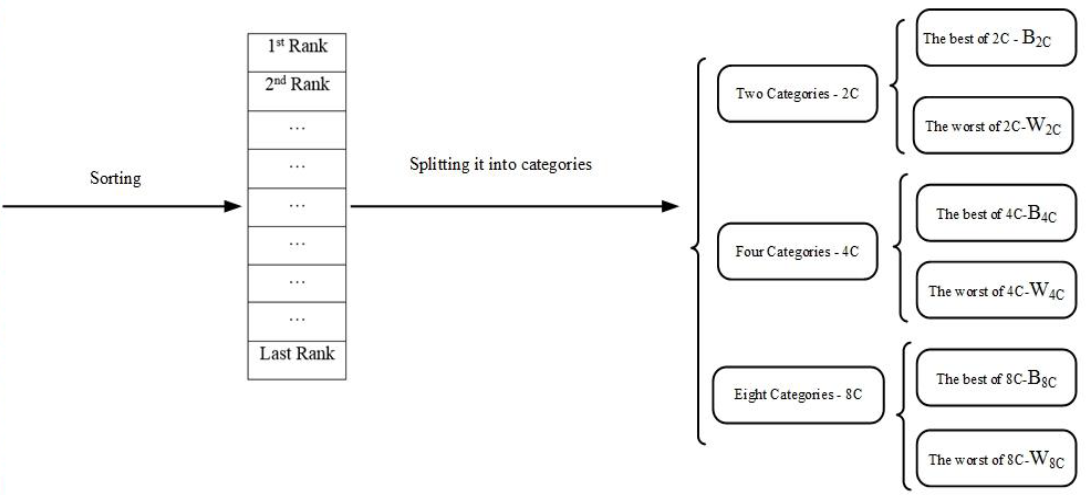

# 2.1.- **The Best and the Worst according to '*Productivity*'**

In [ ]:
# Test
# import pandas as pd

# df_fabc = pd.DataFrame({'Produtividade [kg/ha]': range (1, 10001)})
# df_fabc

In [ ]:
def df_quartile(df, criterion, porc=0.25, quartile="first", ascending=False): # data_frame, column of ranking, porcentagem dos melhores, ascending=False-->best ascending=True-->worst
  #quartile = 'first', 'second', 'third', 'fourth', 'center' (1/4 around median)
  qsize = -1 + int(df[df.columns[0]].count() * porc)
  dic = {'first':(0*qsize, 1*qsize-1), 'second':(1*qsize, 2*qsize-1), 'center':(int(1.5*qsize), int(2.5*qsize)-1), 'third':(2*qsize, 3*qsize-1), 'fourth':(3*qsize+1, 4*qsize)}
  #print(dic)
  #print(dic[quartile][0],dic[quartile][1])
  dfsor = df.sort_values([criterion], ascending = [ascending])  #, [,'Produção [ton]',], ascending = [False,False,True])
  dfqua = pd.DataFrame(dfsor.iloc[dic[quartile][0]:dic[quartile][1]].copy(deep=True))
  return dfqua

In [ ]:
B2C = df_quartile(df_fabc, 'Produtividade [kg/ha]', porc=0.50, quartile="first", ascending=False)
W2C = df_quartile(df_fabc, 'Produtividade [kg/ha]', porc=0.50, quartile="first", ascending=True)
B4C = df_quartile(df_fabc, 'Produtividade [kg/ha]', porc=0.25, quartile="first", ascending=False)
W4C = df_quartile(df_fabc, 'Produtividade [kg/ha]', porc=0.25, quartile="first", ascending=True)
B8C = df_quartile(df_fabc, 'Produtividade [kg/ha]', porc=0.125, quartile="first", ascending=False)
W8C = df_quartile(df_fabc, 'Produtividade [kg/ha]', porc=0.125, quartile="first", ascending=True)

In [ ]:
# print(df_fabc.shape)
print(B2C.shape)
print(W2C.shape)
print(B4C.shape)
print(W4C.shape)
print(B8C.shape)
print(W8C.shape)

(746, 203)
(746, 203)
(372, 203)
(372, 203)
(185, 203)
(185, 203)


In [ ]:
df_fabc['Produtividade [kg/ha]'].describe()

,Produtividade [kg/ha]
count,1496.000000
mean,4117.751297
std,692.926717
min,1186.310000
25%,3650.000000
50%,4190.000000
75%,4608.500000
max,5890.020000


In [ ]:
B2C['Produtividade [kg/ha]'].describe()

,Produtividade [kg/ha]
count,746.000000
mean,4665.692815
std,324.017780
min,4190.690000
25%,4410.030000
50%,4610.000000
75%,4859.517500
max,5890.020000


In [ ]:
W2C['Produtividade [kg/ha]'].describe()

,Produtividade [kg/ha]
count,746.000000
mean,3569.422386
std,506.745205
min,1186.310000
25%,3338.485000
50%,3650.000000
75%,3994.182500
max,4190.000000


In [ ]:
B4C['Produtividade [kg/ha]'].describe()

,Produtividade [kg/ha]
count,372.000000
mean,4922.253468
std,256.269961
min,4610.070000
25%,4714.000000
50%,4861.760000
75%,5088.492500
max,5890.020000


In [ ]:
W4C['Produtividade [kg/ha]'].describe()

,Produtividade [kg/ha]
count,372.000000
mean,3175.950269
std,428.781257
min,1186.310000
25%,2874.750000
50%,3333.900000
75%,3500.000000
max,3650.000000


In [ ]:
B8C['Produtividade [kg/ha]'].describe()

,Produtividade [kg/ha]
count,185.000000
mean,5124.871568
std,211.915086
min,4864.810000
25%,4953.000000
50%,5096.660000
75%,5222.000000
max,5890.020000


In [ ]:
W8C['Produtividade [kg/ha]'].describe()

,Produtividade [kg/ha]
count,185.000000
mean,2847.975297
std,383.468768
min,1186.310000
25%,2645.000000
50%,2868.000000
75%,3105.000000
max,3330.800000


/tmp/ipykernel_581/465794795.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Label', y='Produtividade [kg/ha]', data=df_combined, palette='viridis', inner='point', density_norm='width')


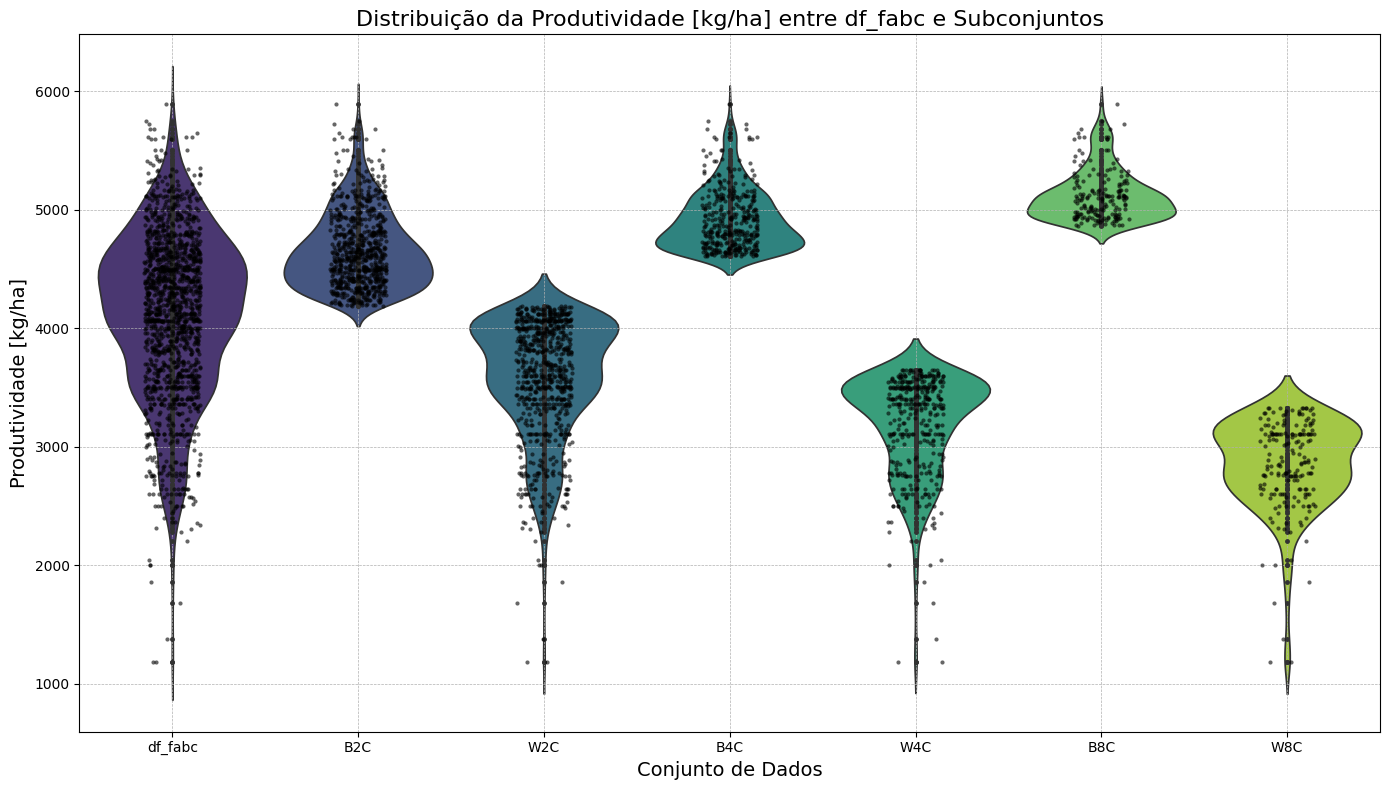

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Certifique-se de que cada DataFrame tenha uma coluna que identifique o grupo ao qual pertence
df_fabc['Label'] = 'df_fabc'
B2C['Label'] = 'B2C'
W2C['Label'] = 'W2C'
B4C['Label'] = 'B4C'
W4C['Label'] = 'W4C'
B8C['Label'] = 'B8C'
W8C['Label'] = 'W8C'

# Concatenar todos os DataFrames em um único
dataframes = [df_fabc, B2C, W2C, B4C, W4C, B8C, W8C]
df_combined = pd.concat(dataframes)

plt.figure(figsize=(14, 8))

# Desenhar o gráfico de violino adaptado às novas recomendações
sns.violinplot(x='Label', y='Produtividade [kg/ha]', data=df_combined, palette='viridis', inner='point', density_norm='width')

# Adicionar o gráfico de distribuição de pontos sobre os violinos
sns.stripplot(x='Label', y='Produtividade [kg/ha]', data=df_combined, color='k', alpha=0.6, jitter=0.15, size=3, dodge=False)

plt.title('Distribuição da Produtividade [kg/ha] entre df_fabc e Subconjuntos', fontsize=16)
plt.ylabel('Produtividade [kg/ha]', fontsize=14)
plt.xlabel('Conjunto de Dados', fontsize=14)
plt.grid(True, which='major', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

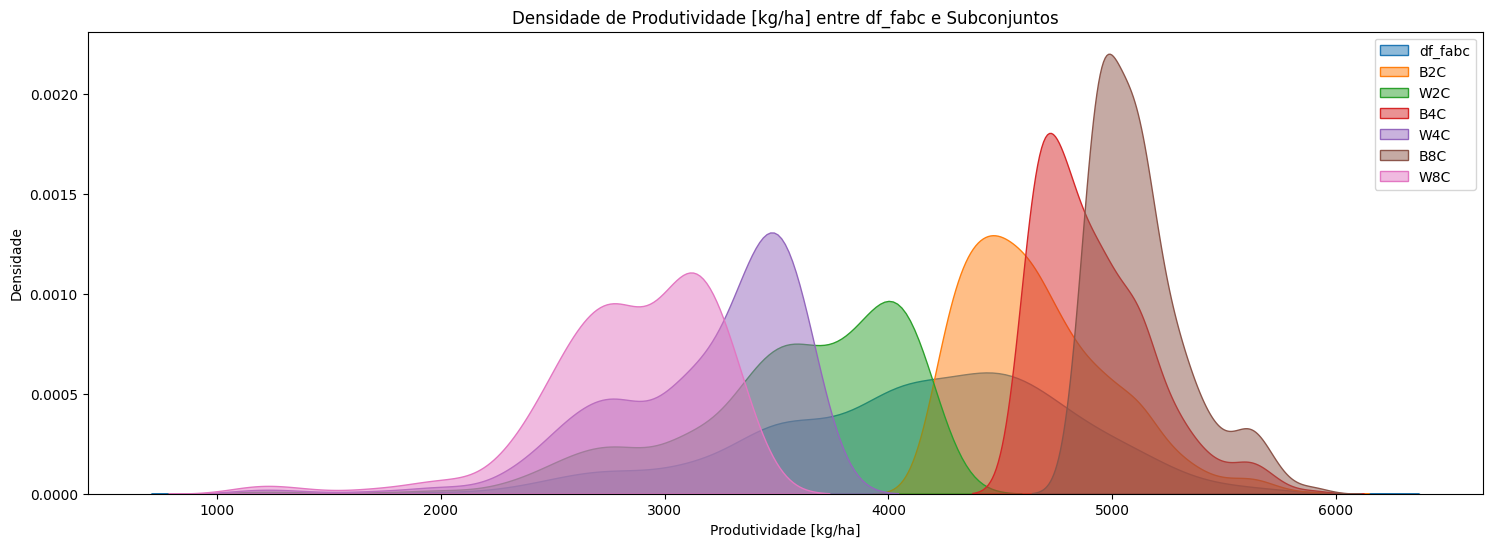

In [ ]:
plt.figure(figsize=(18, 6))

# Adicionar cada conjunto de dados ao gráfico de densidade
for df, label in zip(dataframes, ['df_fabc', 'B2C', 'W2C', 'B4C', 'W4C', 'B8C', 'W8C']):
    sns.kdeplot(df['Produtividade [kg/ha]'], label=label, fill=True, alpha=0.5)

plt.title('Densidade de Produtividade [kg/ha] entre df_fabc e Subconjuntos')
plt.xlabel('Produtividade [kg/ha]')
plt.ylabel('Densidade')
plt.legend()
plt.show()

# 2.2.- SM constructs six phylogram-based models.

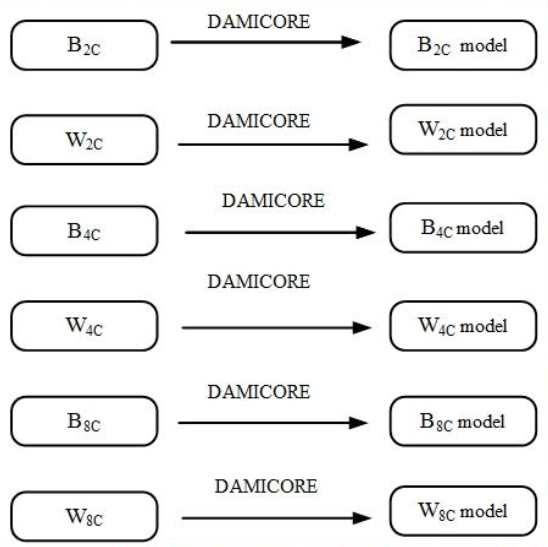

# 2.2.1.- Variable to Unit File Conversion for B2C, W2C, B4C, W4C, B8C, W8C

##B2C

In [ ]:
!pip install unidecode

In [ ]:
import os
from unidecode import unidecode

# 1. Criar a pasta de destino ANTES do loop (se ela não existir)
b2c_dir = "/content/drive/MyDrive/FABC/Etapa13/data3/B2C"
os.makedirs(b2c_dir, exist_ok=True)

dic = {}
fnamel = []
k = 0
chars2replac = ['_', ' ', '[', ']', '/', '<', '>', '.', '%', '=', '(', ')']

for i in B2C.columns:
    fname = str(i)
    fname = unidecode(fname)
    for c in chars2replac:
        fname = fname.replace(c, '')

    dic[fname] = str(i)  # Dicionário para conversões futuras

    # 2. Montar o caminho completo do arquivo
    full_path = os.path.join(b2c_dir, fname)
    print(full_path)

    fnamel.append(full_path)

    # 3. Escrever o arquivo CSV
    with open(full_path, 'w') as f:
        B2C[i].to_csv(f)
        k += 1

print(f"Verificador de éxito: {k} arquivos escritos.")

/content/drive/MyDrive/FABC/Etapa13/data3/B2C/CooperativaID
/content/drive/MyDrive/FABC/Etapa13/data3/B2C/Safra
/content/drive/MyDrive/FABC/Etapa13/data3/B2C/TipoSafra
/content/drive/MyDrive/FABC/Etapa13/data3/B2C/Municipio
/content/drive/MyDrive/FABC/Etapa13/data3/B2C/UF
/content/drive/MyDrive/FABC/Etapa13/data3/B2C/AssistenteTecnicoID
/content/drive/MyDrive/FABC/Etapa13/data3/B2C/ProdutorID
/content/drive/MyDrive/FABC/Etapa13/data3/B2C/Fazenda
/content/drive/MyDrive/FABC/Etapa13/data3/B2C/Talhao
/content/drive/MyDrive/FABC/Etapa13/data3/B2C/Longitude
/content/drive/MyDrive/FABC/Etapa13/data3/B2C/Latitude
/content/drive/MyDrive/FABC/Etapa13/data3/B2C/ClasseSoloBR
/content/drive/MyDrive/FABC/Etapa13/data3/B2C/SoloTextura
/content/drive/MyDrive/FABC/Etapa13/data3/B2C/SoloRelevo
/content/drive/MyDrive/FABC/Etapa13/data3/B2C/SoloClasse
/content/drive/MyDrive/FABC/Etapa13/data3/B2C/AltitudeMinm
/content/drive/MyDrive/FABC/Etapa13/data3/B2C/AltitudeMedm
/content/drive/MyDrive/FABC/Etapa13/d

##W2C

In [ ]:
import os
from unidecode import unidecode

# 1. Definir o diretório W2C e criá-lo ANTES do loop se não existir
w2c_dir = "/content/drive/MyDrive/FABC/Etapa13/data3/W2C"
os.makedirs(w2c_dir, exist_ok=True)

dic = {}
fnamel = []
k = 0
chars2replac = ['_', ' ', '[', ']', '/', '<', '>', '.', '%', '=', '(', ')']

for i in W2C.columns:
    fname = str(i)
    # Transliterar caracteres especiais para ASCII
    fname = unidecode(fname)
    for c in chars2replac:
        fname = fname.replace(c, '')

    dic[fname] = str(i)  # Dicionário para conversões futuras

    # 2. Montar o caminho completo de forma segura
    full_path = os.path.join(w2c_dir, fname)
    print(full_path)

    fnamel.append(full_path)

    # 3. Salvar cada coluna como CSV
    with open(full_path, 'w') as f:
        W2C[i].to_csv(f)
        k += 1

print(f"Verificador de sucesso: {k} arquivos escritos em '{w2c_dir}'.")

/content/drive/MyDrive/FABC/Etapa13/data3/W2C/CooperativaID
/content/drive/MyDrive/FABC/Etapa13/data3/W2C/Safra
/content/drive/MyDrive/FABC/Etapa13/data3/W2C/TipoSafra
/content/drive/MyDrive/FABC/Etapa13/data3/W2C/Municipio
/content/drive/MyDrive/FABC/Etapa13/data3/W2C/UF
/content/drive/MyDrive/FABC/Etapa13/data3/W2C/AssistenteTecnicoID
/content/drive/MyDrive/FABC/Etapa13/data3/W2C/ProdutorID
/content/drive/MyDrive/FABC/Etapa13/data3/W2C/Fazenda
/content/drive/MyDrive/FABC/Etapa13/data3/W2C/Talhao
/content/drive/MyDrive/FABC/Etapa13/data3/W2C/Longitude
/content/drive/MyDrive/FABC/Etapa13/data3/W2C/Latitude
/content/drive/MyDrive/FABC/Etapa13/data3/W2C/ClasseSoloBR
/content/drive/MyDrive/FABC/Etapa13/data3/W2C/SoloTextura
/content/drive/MyDrive/FABC/Etapa13/data3/W2C/SoloRelevo
/content/drive/MyDrive/FABC/Etapa13/data3/W2C/SoloClasse
/content/drive/MyDrive/FABC/Etapa13/data3/W2C/AltitudeMinm
/content/drive/MyDrive/FABC/Etapa13/data3/W2C/AltitudeMedm
/content/drive/MyDrive/FABC/Etapa13/d

##B4C

In [ ]:
import os
from unidecode import unidecode

# 1. Definir o diretório B4C e criá-lo ANTES do loop se não existir
b4c_dir = "/content/drive/MyDrive/FABC/Etapa13/data3/B4C"
os.makedirs(b4c_dir, exist_ok=True)

dic = {}
fnamel = []
k = 0
chars2replac = ['_', ' ', '[', ']', '/', '<', '>', '.', '%', '=', '(', ')']

for i in B4C.columns:
    fname = str(i)
    # Transliterar caracteres especiais para ASCII
    fname = unidecode(fname)
    for c in chars2replac:
        fname = fname.replace(c, '')

    dic[fname] = str(i)  # Dicionário para conversões futuras

    # 2. Montar o caminho completo de forma segura
    full_path = os.path.join(b4c_dir, fname)
    print(full_path)

    fnamel.append(full_path)

    # 3. Salvar cada coluna em formato CSV
    with open(full_path, 'w') as f:
        B4C[i].to_csv(f)
        k += 1

print(f"Verificador de sucesso: {k} arquivos escritos em '{b4c_dir}'.")

/content/drive/MyDrive/FABC/Etapa13/data3/B4C/CooperativaID
/content/drive/MyDrive/FABC/Etapa13/data3/B4C/Safra
/content/drive/MyDrive/FABC/Etapa13/data3/B4C/TipoSafra
/content/drive/MyDrive/FABC/Etapa13/data3/B4C/Municipio
/content/drive/MyDrive/FABC/Etapa13/data3/B4C/UF
/content/drive/MyDrive/FABC/Etapa13/data3/B4C/AssistenteTecnicoID
/content/drive/MyDrive/FABC/Etapa13/data3/B4C/ProdutorID
/content/drive/MyDrive/FABC/Etapa13/data3/B4C/Fazenda
/content/drive/MyDrive/FABC/Etapa13/data3/B4C/Talhao
/content/drive/MyDrive/FABC/Etapa13/data3/B4C/Longitude
/content/drive/MyDrive/FABC/Etapa13/data3/B4C/Latitude
/content/drive/MyDrive/FABC/Etapa13/data3/B4C/ClasseSoloBR
/content/drive/MyDrive/FABC/Etapa13/data3/B4C/SoloTextura
/content/drive/MyDrive/FABC/Etapa13/data3/B4C/SoloRelevo
/content/drive/MyDrive/FABC/Etapa13/data3/B4C/SoloClasse
/content/drive/MyDrive/FABC/Etapa13/data3/B4C/AltitudeMinm
/content/drive/MyDrive/FABC/Etapa13/data3/B4C/AltitudeMedm
/content/drive/MyDrive/FABC/Etapa13/d

##W4C

In [ ]:
import os
from unidecode import unidecode

# 1. Definir o diretório W4C e garanti-lo ANTES do loop
w4c_dir = "/content/drive/MyDrive/FABC/Etapa13/data3/W4C"
os.makedirs(w4c_dir, exist_ok=True)

dic = {}
fnamel = []
k = 0
chars2replac = ['_', ' ', '[', ']', '/', '<', '>', '.', '%', '=', '(', ')']

for i in W4C.columns:
    fname = str(i)
    # Transliterar caracteres especiais para ASCII
    fname = unidecode(fname)
    for c in chars2replac:
        fname = fname.replace(c, '')

    dic[fname] = str(i)  # Dicionário para conversões futuras

    # 2. Montar o caminho completo do arquivo
    full_path = os.path.join(w4c_dir, fname)
    print(full_path)

    fnamel.append(full_path)

    # 3. Salvar cada coluna em formato CSV
    with open(full_path, 'w') as f:
        W4C[i].to_csv(f)
        k += 1

print(f"Verificador de sucesso: {k} arquivos escritos em '{w4c_dir}'.")

/content/drive/MyDrive/FABC/Etapa13/data3/W4C/CooperativaID
/content/drive/MyDrive/FABC/Etapa13/data3/W4C/Safra
/content/drive/MyDrive/FABC/Etapa13/data3/W4C/TipoSafra
/content/drive/MyDrive/FABC/Etapa13/data3/W4C/Municipio
/content/drive/MyDrive/FABC/Etapa13/data3/W4C/UF
/content/drive/MyDrive/FABC/Etapa13/data3/W4C/AssistenteTecnicoID
/content/drive/MyDrive/FABC/Etapa13/data3/W4C/ProdutorID
/content/drive/MyDrive/FABC/Etapa13/data3/W4C/Fazenda
/content/drive/MyDrive/FABC/Etapa13/data3/W4C/Talhao
/content/drive/MyDrive/FABC/Etapa13/data3/W4C/Longitude
/content/drive/MyDrive/FABC/Etapa13/data3/W4C/Latitude
/content/drive/MyDrive/FABC/Etapa13/data3/W4C/ClasseSoloBR
/content/drive/MyDrive/FABC/Etapa13/data3/W4C/SoloTextura
/content/drive/MyDrive/FABC/Etapa13/data3/W4C/SoloRelevo
/content/drive/MyDrive/FABC/Etapa13/data3/W4C/SoloClasse
/content/drive/MyDrive/FABC/Etapa13/data3/W4C/AltitudeMinm
/content/drive/MyDrive/FABC/Etapa13/data3/W4C/AltitudeMedm
/content/drive/MyDrive/FABC/Etapa13/d

##B8C

In [ ]:
import os
from unidecode import unidecode

# 1. Definir o diretório B8C e garanti-lo ANTES do loop
b8c_dir = "/content/drive/MyDrive/FABC/Etapa13/data3/B8C"
os.makedirs(b8c_dir, exist_ok=True)

dic = {}
fnamel = []
k = 0
chars2replac = ['_', ' ', '[', ']', '/', '<', '>', '.', '%', '=', '(', ')']

for i in B8C.columns:
    fname = str(i)
    # Transliterar caracteres especiais para ASCII
    fname = unidecode(fname)
    for c in chars2replac:
        fname = fname.replace(c, '')

    dic[fname] = str(i)  # Dicionário para conversões futuras

    # 2. Montar o caminho completo de forma segura
    full_path = os.path.join(b8c_dir, fname)
    print(full_path)

    fnamel.append(full_path)

    # 3. Salvar cada coluna em formato CSV
    with open(full_path, 'w') as f:
        B8C[i].to_csv(f)
        k += 1

print(f"Verificador de sucesso: {k} arquivos escritos em '{b8c_dir}'.")

/content/drive/MyDrive/FABC/Etapa13/data3/B8C/CooperativaID
/content/drive/MyDrive/FABC/Etapa13/data3/B8C/Safra
/content/drive/MyDrive/FABC/Etapa13/data3/B8C/TipoSafra
/content/drive/MyDrive/FABC/Etapa13/data3/B8C/Municipio
/content/drive/MyDrive/FABC/Etapa13/data3/B8C/UF
/content/drive/MyDrive/FABC/Etapa13/data3/B8C/AssistenteTecnicoID
/content/drive/MyDrive/FABC/Etapa13/data3/B8C/ProdutorID
/content/drive/MyDrive/FABC/Etapa13/data3/B8C/Fazenda
/content/drive/MyDrive/FABC/Etapa13/data3/B8C/Talhao
/content/drive/MyDrive/FABC/Etapa13/data3/B8C/Longitude
/content/drive/MyDrive/FABC/Etapa13/data3/B8C/Latitude
/content/drive/MyDrive/FABC/Etapa13/data3/B8C/ClasseSoloBR
/content/drive/MyDrive/FABC/Etapa13/data3/B8C/SoloTextura
/content/drive/MyDrive/FABC/Etapa13/data3/B8C/SoloRelevo
/content/drive/MyDrive/FABC/Etapa13/data3/B8C/SoloClasse
/content/drive/MyDrive/FABC/Etapa13/data3/B8C/AltitudeMinm
/content/drive/MyDrive/FABC/Etapa13/data3/B8C/AltitudeMedm
/content/drive/MyDrive/FABC/Etapa13/d

##W8C

In [ ]:
import os
from unidecode import unidecode

# 1. Definir o diretório W8C e garanti-lo ANTES do loop
w8c_dir = "/content/drive/MyDrive/FABC/Etapa13/data3/W8C"
os.makedirs(w8c_dir, exist_ok=True)

dic = {}
fnamel = []
k = 0
chars2replac = ['_', ' ', '[', ']', '/', '<', '>', '.', '%', '=', '(', ')']

for i in W8C.columns:
    fname = str(i)
    # Transliterar caracteres especiais para ASCII
    fname = unidecode(fname)
    for c in chars2replac:
        fname = fname.replace(c, '')

    dic[fname] = str(i)  # Dicionário para conversões futuras

    # 2. Montar o caminho completo de forma segura
    full_path = os.path.join(w8c_dir, fname)
    print(full_path)

    fnamel.append(full_path)

    # 3. Salvar cada coluna em formato CSV
    with open(full_path, 'w') as f:
        W8C[i].to_csv(f)
        k += 1

print(f"Verificador de sucesso: {k} arquivos escritos em '{w8c_dir}'.")

/content/drive/MyDrive/FABC/Etapa13/data3/W8C/CooperativaID
/content/drive/MyDrive/FABC/Etapa13/data3/W8C/Safra
/content/drive/MyDrive/FABC/Etapa13/data3/W8C/TipoSafra
/content/drive/MyDrive/FABC/Etapa13/data3/W8C/Municipio
/content/drive/MyDrive/FABC/Etapa13/data3/W8C/UF
/content/drive/MyDrive/FABC/Etapa13/data3/W8C/AssistenteTecnicoID
/content/drive/MyDrive/FABC/Etapa13/data3/W8C/ProdutorID
/content/drive/MyDrive/FABC/Etapa13/data3/W8C/Fazenda
/content/drive/MyDrive/FABC/Etapa13/data3/W8C/Talhao
/content/drive/MyDrive/FABC/Etapa13/data3/W8C/Longitude
/content/drive/MyDrive/FABC/Etapa13/data3/W8C/Latitude
/content/drive/MyDrive/FABC/Etapa13/data3/W8C/ClasseSoloBR
/content/drive/MyDrive/FABC/Etapa13/data3/W8C/SoloTextura
/content/drive/MyDrive/FABC/Etapa13/data3/W8C/SoloRelevo
/content/drive/MyDrive/FABC/Etapa13/data3/W8C/SoloClasse
/content/drive/MyDrive/FABC/Etapa13/data3/W8C/AltitudeMinm
/content/drive/MyDrive/FABC/Etapa13/data3/W8C/AltitudeMedm
/content/drive/MyDrive/FABC/Etapa13/d

#2.2.2.- DAMICORE for B2C, W2C, B4C, W4C, B8C, W8C

In [ ]:
!pip install git+https://gitlab.uspdigital.usp.br/jjuarez/damicore.git

  Cloning https://gitlab.uspdigital.usp.br/jjuarez/damicore.git to /tmp/pip-req-build-dhiwkoha
  Running command git clone --filter=blob:none --quiet https://gitlab.uspdigital.usp.br/jjuarez/damicore.git /tmp/pip-req-build-dhiwkoha
  Resolved https://gitlab.uspdigital.usp.br/jjuarez/damicore.git to commit 2658a59b24967bb9654e193cbff184b898d800b2
  Preparing metadata (setup.py) ... done


In [ ]:
# # forzar reinstall
# !pip install --upgrade --force-reinstall git+https://gitlab.uspdigital.usp.br/jjuarez/damicore.git

In [ ]:
!pip install python-igraph

In [ ]:
## Localizing damicore
!pip list -v | grep damicore

damicore                              0.1.0               /usr/local/lib/python3.13/dist-packages pip


In [ ]:
import os
import sys

# Detecta a versão atual (ex: '3.12')
py_version = f"{sys.version_info.major}.{sys.version_info.minor}"
path = f'/usr/local/lib/python{py_version}/dist-packages/damicore/'

os.chdir(path)

In [ ]:
## Importing modules from damicore to run
import damicore as dm

## DAMICORE for B2C

In [ ]:
# damicore para una carpeta
import os

# Results directory
output_dir = "/content/drive/MyDrive/FABC/Etapa13/data3/B2Coutput"

# Ensure the results directory exists
os.makedirs(output_dir, exist_ok=True)

# Count how many result files already exist to avoid overwriting
existing_files = os.listdir(output_dir)
max_num = 0
for file in existing_files:
    if "-" in file:
    # if file.endswith(".txt"):
        num = int(file.split("-")[0])
        if num > max_num:
            max_num = num
next_num = max_num + 1

# Arguments for DAMICORE
argv = [
    "damicore.py",
    "/content/drive/MyDrive/FABC/Etapa13/data3/B2C/",
    "--compressor", "gzip",
    "--tree-output", os.path.join(output_dir, f"{next_num}-tree.newick"),
    "--output", os.path.join(output_dir, f"{next_num}-membership.csv"),
    "--partition-output", os.path.join(output_dir, f"{next_num}-partition.csv"),
    "--ncd-output", os.path.join(output_dir, f"{next_num}-ncd.csv"),
    "--community-detection", "fast"
]

# Save the used arguments
with open(os.path.join(output_dir, f"{next_num}-args.txt"), 'w') as f:
    f.write(" ".join(argv))

args = argv[1:]

args #ejcutar

# Calls the 'main' function from the 'dm' #ejecutar
dm.main(args)

Performing NCD distance matrix calculation...
Compressing individual sources...
Compressing source pairs...
Simplifying graph...
Clustering elements...


## DAMICORE for W2C

In [ ]:
# damicore para una carpeta
import os

# Results directory
output_dir = "/content/drive/MyDrive/FABC/Etapa13/data3/W2Coutput"

# Ensure the results directory exists
os.makedirs(output_dir, exist_ok=True)

# Count how many result files already exist to avoid overwriting
existing_files = os.listdir(output_dir)
max_num = 0
for file in existing_files:
    if "-" in file:
    # if file.endswith(".txt"):
        num = int(file.split("-")[0])
        if num > max_num:
            max_num = num
next_num = max_num + 1

# Arguments for DAMICORE
argv = [
    "damicore.py",
    "/content/drive/MyDrive/FABC/Etapa13/data3/W2C/",
    "--compressor", "gzip",
    "--tree-output", os.path.join(output_dir, f"{next_num}-tree.newick"),
    "--output", os.path.join(output_dir, f"{next_num}-membership.csv"),
    "--partition-output", os.path.join(output_dir, f"{next_num}-partition.csv"),
    "--ncd-output", os.path.join(output_dir, f"{next_num}-ncd.csv"),
    "--community-detection", "fast"
]

# Save the used arguments
with open(os.path.join(output_dir, f"{next_num}-args.txt"), 'w') as f:
    f.write(" ".join(argv))

args = argv[1:]

args #ejcutar

# Calls the 'main' function from the 'dm' #ejecutar
dm.main(args)

Performing NCD distance matrix calculation...
Compressing individual sources...
Compressing source pairs...
Simplifying graph...
Clustering elements...


## DAMICORE for B4C

In [ ]:
import os
import shutil

# 1. Definir caminhos no Drive e no Disco Local do Colab
drive_input_dir = "/content/drive/MyDrive/FABC/Etapa13/data3/B4C"
drive_output_dir = "/content/drive/MyDrive/FABC/Etapa13/data3/B4Coutput"

local_input_dir = "/content/B4C_local"
local_output_dir = "/content/B4Coutput_local"

# 2. Copiar os arquivos de entrada para a memória local do Colab
os.makedirs(local_output_dir, exist_ok=True)
if os.path.exists(local_input_dir):
    shutil.rmtree(local_input_dir)
shutil.copytree(drive_input_dir, local_input_dir)

print("⚡ Arquivos copiados para o disco local. Executando DAMICORE...")

# 3. Lógica do prefixo incremental
os.makedirs(drive_output_dir, exist_ok=True)
existing_files = os.listdir(drive_output_dir)
max_num = max([int(f.split("-")[0]) for f in existing_files if "-" in f and f.split("-")[0].isdigit()] or [0])
next_num = max_num + 1

# 4. Argumentos do DAMICORE utilizando a pasta LOCAL
argv = [
    "damicore.py",
    local_input_dir,
    "--compressor", "gzip",
    "--tree-output", os.path.join(local_output_dir, f"{next_num}-tree.newick"),
    "--output", os.path.join(local_output_dir, f"{next_num}-membership.csv"),
    "--partition-output", os.path.join(local_output_dir, f"{next_num}-partition.csv"),
    "--ncd-output", os.path.join(local_output_dir, f"{next_num}-ncd.csv"),
    "--community-detection", "fast"
]

# Salvar argumentos no disco local
with open(os.path.join(local_output_dir, f"{next_num}-args.txt"), 'w') as f:
    f.write(" ".join(argv))

# Execução no disco local
dm.main(argv[1:])

# 5. Mover apenas os arquivos gerados de volta para o Google Drive
for item in os.listdir(local_output_dir):
    shutil.copy(os.path.join(local_output_dir, item), drive_output_dir)

print(f"✅ Execução concluída! Resultados copiados com sucesso para: '{drive_output_dir}'")

⚡ Arquivos copiados para o disco local. Executando DAMICORE...


Performing NCD distance matrix calculation...
Compressing individual sources...
Compressing source pairs...
Simplifying graph...


✅ Execução concluída! Resultados copiados com sucesso para: '/content/drive/MyDrive/FABC/Etapa13/data3/B4Coutput'


Clustering elements...


## DAMICORE for W4C

In [ ]:
# damicore para una carpeta
import os

# Results directory
output_dir = "/content/drive/MyDrive/FABC/Etapa13/data3/W4Coutput"

# Ensure the results directory exists
os.makedirs(output_dir, exist_ok=True)

# Count how many result files already exist to avoid overwriting
existing_files = os.listdir(output_dir)
max_num = 0
for file in existing_files:
    if "-" in file:
    # if file.endswith(".txt"):
        num = int(file.split("-")[0])
        if num > max_num:
            max_num = num
next_num = max_num + 1

# Arguments for DAMICORE
argv = [
    "damicore.py",
    "/content/drive/MyDrive/FABC/Etapa13/data3/W4C/",
    "--compressor", "gzip",
    "--tree-output", os.path.join(output_dir, f"{next_num}-tree.newick"),
    "--output", os.path.join(output_dir, f"{next_num}-membership.csv"),
    "--partition-output", os.path.join(output_dir, f"{next_num}-partition.csv"),
    "--ncd-output", os.path.join(output_dir, f"{next_num}-ncd.csv"),
    "--community-detection", "fast"
]

# Save the used arguments
with open(os.path.join(output_dir, f"{next_num}-args.txt"), 'w') as f:
    f.write(" ".join(argv))

args = argv[1:]

args #ejcutar

# Calls the 'main' function from the 'dm' #ejecutar
dm.main(args)

Performing NCD distance matrix calculation...
Compressing individual sources...
Compressing source pairs...
Simplifying graph...
Clustering elements...


## DAMICORE for B8C

In [ ]:
# damicore para una carpeta
import os

# Results directory
output_dir = "/content/drive/MyDrive/FABC/Etapa13/data3/B8Coutput"

# Ensure the results directory exists
os.makedirs(output_dir, exist_ok=True)

# Count how many result files already exist to avoid overwriting
existing_files = os.listdir(output_dir)
max_num = 0
for file in existing_files:
    if "-" in file:
    # if file.endswith(".txt"):
        num = int(file.split("-")[0])
        if num > max_num:
            max_num = num
next_num = max_num + 1

# Arguments for DAMICORE
argv = [
    "damicore.py",
    "/content/drive/MyDrive/FABC/Etapa13/data3/B8C/",
    "--compressor", "gzip",
    "--tree-output", os.path.join(output_dir, f"{next_num}-tree.newick"),
    "--output", os.path.join(output_dir, f"{next_num}-membership.csv"),
    "--partition-output", os.path.join(output_dir, f"{next_num}-partition.csv"),
    "--ncd-output", os.path.join(output_dir, f"{next_num}-ncd.csv"),
    "--community-detection", "fast"
]

# Save the used arguments
with open(os.path.join(output_dir, f"{next_num}-args.txt"), 'w') as f:
    f.write(" ".join(argv))

args = argv[1:]

args #ejcutar

# Calls the 'main' function from the 'dm' #ejecutar
dm.main(args)

Performing NCD distance matrix calculation...
Compressing individual sources...
Compressing source pairs...
Simplifying graph...
Clustering elements...


## DAMICORE for W8C

In [ ]:
# damicore para una carpeta
import os

# Results directory
output_dir = "/content/drive/MyDrive/FABC/Etapa13/data3/W8Coutput"

# Ensure the results directory exists
os.makedirs(output_dir, exist_ok=True)

# Count how many result files already exist to avoid overwriting
existing_files = os.listdir(output_dir)
max_num = 0
for file in existing_files:
    if "-" in file:
    # if file.endswith(".txt"):
        num = int(file.split("-")[0])
        if num > max_num:
            max_num = num
next_num = max_num + 1

# Arguments for DAMICORE
argv = [
    "damicore.py",
    "/content/drive/MyDrive/FABC/Etapa13/data3/W8C/",
    "--compressor", "gzip",
    "--tree-output", os.path.join(output_dir, f"{next_num}-tree.newick"),
    "--output", os.path.join(output_dir, f"{next_num}-membership.csv"),
    "--partition-output", os.path.join(output_dir, f"{next_num}-partition.csv"),
    "--ncd-output", os.path.join(output_dir, f"{next_num}-ncd.csv"),
    "--community-detection", "fast"
]

# Save the used arguments
with open(os.path.join(output_dir, f"{next_num}-args.txt"), 'w') as f:
    f.write(" ".join(argv))

args = argv[1:]

args #ejcutar

# Calls the 'main' function from the 'dm' #ejecutar
dm.main(args)

Performing NCD distance matrix calculation...
Compressing individual sources...
Compressing source pairs...
Simplifying graph...
Clustering elements...


#2.2.3.- Investigate a tree from the best quartile using a target 'Produtividade'

In [ ]:
from google.colab import files
files.upload()

Saving 1-tree.newick to 1-tree.newick


{'1-tree.newick': b"((((((((((((((('AltitudeClasse':0.7966626553320344,'AltitudeMaxm':0.8268092273085523):0.03875301267401432,'AltitudeMinm':0.870776417511347):0.035584095284300676,'AltitudeDiferenca':0.9170495173827125):0.012195128914683773,('AreaColhidaha':0.2041257631422606,'AreaInsumoha':0.20966734030601525):0.7188074673058698):0.019404406653223072,'AltitudeMedm':0.9414893312406156):0.056512253934489484,((('Ciclodias':0.8583540814370066,'DATA':0.8265094421361944):0.09620809789294602,('ColheitaDecendio':0.9147495291881669,(((('DIRVT2M1stQ':0.3235864477988192,('DIRVT2M3stQ':0.31228011675129236,'DIRVT2MMED':0.31749087561511985):0.009717638071731621):0.009924923124879331,'DIRVT2MMEDIAN':0.323527455659563):0.01491942030562246,('DIRVT2MMAX':0.3175726496858309,'DIRVT2MMIN':0.32430601959009864):0.00770291082519911):0.01850885005347494,'DIRVT2MSOMA':0.3711299762222049):0.47081752472566124):0.030846879002420592):0.008392017155362289,(((('FungicidaPlanejado':0.39956399544981397,'InseticidaPla

In [ ]:
!pip install ete3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 119.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for ete3: filename=ete3-3.1.3-py3-none-any.whl size=2273786 sha256=d136e41fb73f44259fab4e44c2f1eca77c2a4f0f807d97f352256067926b303f
  Stored in directory: /root/.cache/pip/wheels/88/cc/c1/0e0d50d8a29caccf5d482d883af1bc9d9af5b043ea108008c8
Successfully built ete3


###B2C Tree

In [ ]:
# 1. Instalar o pacote de compatibilidade do cgi para Python 3.13+
!pip install -q legacy-cgi

# 2. Injetar o patch no sistema ANTES de importar o ete3
import sys
try:
    import cgi
except ImportError:
    import legacy_cgi as cgi
    sys.modules['cgi'] = cgi

# 3. Importar ete3 e carregar a árvore
import os
from ete3 import Tree

# Caminho do arquivo da árvore
output_dir = "/content/drive/MyDrive/FABC/Etapa13/data3/B2Coutput/1-tree.newick"

# Fallback para a pasta antiga caso o caminho acima não exista
if not os.path.exists(output_dir):
    output_dir = "/content/drive/MyDrive/FABC/Etapa13/data/B2Coutput/1-tree.newick"

# Carregar estrutura
tbest = Tree(output_dir, quoted_node_names=True)
print(f"✅ Árvore 'tbest' carregada com sucesso de: {output_dir}")

✅ Árvore 'tbest' carregada com sucesso de: /content/drive/MyDrive/FABC/Etapa13/data3/B2Coutput/1-tree.newick


In [ ]:
print(tbest)


                                             /-AltitudeClasse
                                          /-|
                                       /-|   \-AltitudeMaxm
                                      |  |
                                    /-|   \-AltitudeMinm
                                   |  |
                                   |  |   /-AltitudeDiferenca
                                   |   \-|
                                 /-|     |   /-AreaColhidaha
                                |  |      \-|
                                |  |         \-AreaInsumoha
                                |  |
                                |   \-AltitudeMedm
                                |
                                |               /-DIRVT2M1stQ
                                |            /-|
                                |           |   \-DIRVT2M3stQ
                              /-|         /-|
                             |  |        |  |   /-DIRVT2MMED
                 

In [ ]:
def find_leaf(tree, leaf_name):
  l = [i for i in tree if i.name == leaf_name]
  return l # print(l): [Tree node 'Cultivar' (0x7f75ac2c20f)]  # print(l[0]): --Cultivar  # print(l[0].name): Cultivar

In [ ]:
def layered_subt(tree,leaf):
  tree.set_outgroup(leaf)
  layer, ltrav = [], []
  for i in tree.traverse(strategy='levelorder'):  #depth-first-search result
    if len(i.name)>0:
      layer += [i.name]
    else:
      ltrav += [layer]
      layer = []
  ltravcln = [j for j in ltrav if len(j)>0]
  tree_rooted_at_leaf = tree
  return ltravcln, tree_rooted_at_leaf

In [ ]:
l = find_leaf(tbest,'Produtividadekgha')
leaf = l[0].name
layers, t_nroot = layered_subt(tbest,leaf)

In [ ]:
layers

[['Produtividadekgha'],
 ['ColheitaDecendio'],
 ['FungicidaPlanejado'],
 ['PRECMIN'],
 ['HerbicidaPlanejado', 'InseticidaPlanejado'],
 ['Herbicidaaplicacoes'],
 ['AltitudeMedm'],
 ['Fungicidaaplicacoes', 'Inseticidaaplicacoes'],
 ['DIRVT2MSOMA', 'SoloRelevo', 'SoloTextura'],
 ['Latitude', 'Longitude'],
 ['ProdutorID'],
 ['AltitudeMinm', 'AltitudeDiferenca'],
 ['Cultura', 'DATAJ', 'Label', 'AssistenteTecnicoID', 'CooperativaID'],
 ['codareaestacao'],
 ['AltitudeClasse', 'AltitudeMaxm', 'AreaColhidaha', 'AreaInsumoha'],
 ['DIRVT2MMAX', 'DIRVT2MMIN'],
 ['SemeaduraDecendio', 'UF'],
 ['DIRVT2M1stQ', 'DIRVT2M3stQ', 'DIRVT2MMED', 'DIRVT2MMEDIAN'],
 ['Talhao'],
 ['PRECMAX', 'PRECSOMA'],
 ['Fazenda'],
 ['NHT30', 'NHT35'],
 ['Cultivar', 'ColheitaFinal', 'ColheitaInicial', 'Safra', 'TIPOMANEJO'],
 ['Municipio', 'SemeaduraFinal', 'SemeaduraInicio'],
 ['Producaoton', 'FOTOPERIODOSOMA', 'GDA210'],
 ['NHUR85'],
 ['Proposito', 'ColheitaMes'],
 ['Ciclodias', 'DATA'],
 ['TMEDSOMA', 'GDA25', 'GDA26'],
 [

In [ ]:
print(t_nroot)


   /-Produtividadekgha
  |
  |   /-ColheitaDecendio
  |  |
  |  |         /-FungicidaPlanejado
  |  |      /-|
  |  |     |  |   /-HerbicidaPlanejado
  |  |     |   \-|
  |  |     |      \-InseticidaPlanejado
  |  |   /-|
--|  |  |  |         /-Fungicidaaplicacoes
  |  |  |  |      /-|
  |  |  |  |   /-|   \-Inseticidaaplicacoes
  |  |  |  |  |  |
  |  |  |   \-|   \-Herbicidaaplicacoes
  |  |  |     |
  |  |  |      \-PRECMIN
  |  |  |
  |  |  |                  /-AltitudeClasse
  |  |  |               /-|
   \-|  |            /-|   \-AltitudeMaxm
     |  |           |  |
     |  |         /-|   \-AltitudeMinm
     |  |        |  |
     |  |        |  |   /-AltitudeDiferenca
     |  |        |   \-|
     |  |      /-|     |   /-AreaColhidaha
     |  |     |  |      \-|
     |  |     |  |         \-AreaInsumoha
     |  |     |  |
     |  |     |   \-AltitudeMedm
     |  |     |
     |  |     |               /-DIRVT2M1stQ
     |  |     |            /-|
     |  |     |           |   \-D

In [ ]:
#top layers
def top(layers,ntop=len(layers)-1): # list of nodes from a depth-first seach with a sublist by layer/depth
  assert ntop < len(layers)-1, "List {layers} is smaller than expected"
  k = 0
  top = []
  while k < ntop:
    top += [layers[k]]
    k += 1
  return top

In [ ]:
toptop = top(layers,10)
print(toptop)

[['Produtividadekgha'], ['ColheitaDecendio'], ['FungicidaPlanejado'], ['PRECMIN'], ['HerbicidaPlanejado', 'InseticidaPlanejado'], ['Herbicidaaplicacoes'], ['AltitudeMedm'], ['Fungicidaaplicacoes', 'Inseticidaaplicacoes'], ['DIRVT2MSOMA', 'SoloRelevo', 'SoloTextura'], ['Latitude', 'Longitude']]


In [ ]:
topplain = [j for i in toptop for j in i]
topplain

['Produtividadekgha',
 'ColheitaDecendio',
 'FungicidaPlanejado',
 'PRECMIN',
 'HerbicidaPlanejado',
 'InseticidaPlanejado',
 'Herbicidaaplicacoes',
 'AltitudeMedm',
 'Fungicidaaplicacoes',
 'Inseticidaaplicacoes',
 'DIRVT2MSOMA',
 'SoloRelevo',
 'SoloTextura',
 'Latitude',
 'Longitude']

In [ ]:
t_nroot.prune(topplain)
print(t_nroot)


   /-Produtividadekgha
  |
  |   /-ColheitaDecendio
  |  |
--|  |         /-FungicidaPlanejado
  |  |      /-|
  |  |     |  |   /-HerbicidaPlanejado
  |  |     |   \-|
  |  |     |      \-InseticidaPlanejado
   \-|   /-|
     |  |  |         /-Fungicidaaplicacoes
     |  |  |      /-|
     |  |  |   /-|   \-Inseticidaaplicacoes
     |  |  |  |  |
     |  |   \-|   \-Herbicidaaplicacoes
     |  |     |
      \-|      \-PRECMIN
        |
        |            /-SoloRelevo
        |         /-|
        |      /-|   \-SoloTextura
        |     |  |
        |   /-|   \-DIRVT2MSOMA
        |  |  |
         \-|   \-AltitudeMedm
           |
           |   /-Latitude
            \-|
               \-Longitude


###W2C Tree

In [ ]:
import os
import sys

# Patch de compatibilidade Python 3.13+
try:
    import cgi
except ImportError:
    import legacy_cgi as cgi
    sys.modules['cgi'] = cgi

from ete3 import Tree

# 1. Definir os caminhos possíveis (data3 vs data)
primary_path = "/content/drive/MyDrive/FABC/Etapa13/data3/W2Coutput/1-tree.newick"
secondary_path = "/content/drive/MyDrive/FABC/Etapa13/data/W2Coutput/1-tree.newick"

target_path = primary_path if os.path.exists(primary_path) else secondary_path

# 2. Validação da existência e integridade do arquivo
if not os.path.exists(target_path):
    raise FileNotFoundError(
        f"❌ O arquivo não existe nem em '{primary_path}' nem em '{secondary_path}'. "
        "Certifique-se de que o DAMICORE do W2C terminou de rodar."
    )

if os.path.getsize(target_path) == 0:
    raise ValueError(
        f"❌ O arquivo '{target_path}' existe, mas está vazio (0 bytes). "
        "A execução do DAMICORE foi interrompida antes de salvar a árvore. Re-execute o DAMICORE do W2C."
    )

# 3. Leitura com fallback de formato
print(f"Carregando arquivo: {target_path}")

try:
    # Tenta format=1 (compatível com rótulos de nós internos do DAMICORE)
    tbest = Tree(target_path, format=1, quoted_node_names=True)
except Exception:
    # Fallback para format=0 (formato padrão flexível)
    tbest = Tree(target_path, format=0, quoted_node_names=True)

print("✅ Árvore W2C carregada com sucesso na variável 'tbest'!")

Carregando arquivo: /content/drive/MyDrive/FABC/Etapa13/data3/W2Coutput/1-tree.newick
✅ Árvore W2C carregada com sucesso na variável 'tbest'!


In [ ]:
print(tbest)


                                             /-AltitudeClasse
                                          /-|
                                       /-|   \-AltitudeMaxm
                                      |  |
                                    /-|   \-AltitudeMinm
                                   |  |
                                   |   \-AltitudeDiferenca
                                 /-|
                                |  |      /-AreaColhidaha
                                |  |   /-|
                              /-|   \-|   \-AreaInsumoha
                             |  |     |
                             |  |      \-Producaoton
                           /-|  |
                          |  |   \-AltitudeMedm
                          |  |
                          |   \-ColheitaDecendio
                          |
                          |            /-DIRVT2M1stQ
                          |         /-|
                          |        |  |   /-DIRVT2M3stQ
     

In [ ]:
def find_leaf(tree, leaf_name):
  l = [i for i in tree if i.name == leaf_name]
  return l # print(l): [Tree node 'Cultivar' (0x7f75ac2c20f)]  # print(l[0]): --Cultivar  # print(l[0].name): Cultivar

In [ ]:
def layered_subt(tree,leaf):
  tree.set_outgroup(leaf)
  layer, ltrav = [], []
  for i in tree.traverse(strategy='levelorder'):  #depth-first-search result
    if len(i.name)>0:
      layer += [i.name]
    else:
      ltrav += [layer]
      layer = []
  ltravcln = [j for j in ltrav if len(j)>0]
  tree_rooted_at_leaf = tree
  return ltravcln, tree_rooted_at_leaf

In [ ]:
l = find_leaf(tbest,'Produtividadekgha')
leaf = l[0].name
layers, t_nroot = layered_subt(tbest,leaf)

In [ ]:
layers

[['Produtividadekgha'],
 ['Talhao'],
 ['Ciclodias', 'DATA'],
 ['Fazenda'],
 ['ColheitaMes'],
 ['Latitude', 'Longitude'],
 ['Cultivar'],
 ['SemeaduraFinal', 'SemeaduraInicio', 'Municipio'],
 ['Proposito',
  'ColheitaFinal',
  'ColheitaInicial',
  'Safra',
  'TIPOMANEJO',
  'SemeaduraMes',
  'TipoSafra'],
 ['ColheitaDecendio'],
 ['ClasseSoloBR', 'SoloClasse'],
 ['AltitudeMedm'],
 ['DIRVT2MSOMA', 'SoloRelevo', 'SoloTextura'],
 ['SemeaduraDecendio', 'UF'],
 ['codareaestacao'],
 ['InseticidaPlanejado'],
 ['PRECMIN'],
 ['ProdutorID'],
 ['AltitudeDiferenca'],
 ['Producaoton', 'DIRVT2M1stQ'],
 ['DIRVT2MMAX', 'DIRVT2MMIN', 'FungicidaPlanejado', 'HerbicidaPlanejado'],
 ['Herbicidaaplicacoes',
  'AssistenteTecnicoID',
  'CooperativaID',
  'PREC3stQ',
  'PRECMED',
  'PRECMAX',
  'PRECSOMA'],
 ['AltitudeMinm', 'AreaColhidaha', 'AreaInsumoha', 'DIRVT2M3stQ'],
 ['Fungicidaaplicacoes', 'Inseticidaaplicacoes'],
 ['TMAXMAX', 'TMAXSOMA'],
 ['AltitudeClasse',
  'AltitudeMaxm',
  'DIRVT2MMED',
  'DIRVT2MME

In [ ]:
print(t_nroot)


   /-Produtividadekgha
  |
  |                     /-ClasseSoloBR
  |                  /-|
  |               /-|   \-SoloClasse
  |              |  |
  |            /-|   \-Proposito
  |           |  |
  |         /-|   \-Cultivar
  |        |  |
  |      /-|   \-Fazenda
  |     |  |
  |     |   \-Talhao
  |     |
  |     |            /-ColheitaFinal
--|     |         /-|
  |   /-|        |   \-ColheitaInicial
  |  |  |      /-|
  |  |  |     |  |   /-Safra
  |  |  |     |   \-|
  |  |  |   /-|      \-TIPOMANEJO
  |  |  |  |  |
  |  |  |  |  |   /-SemeaduraFinal
  |  |   \-|   \-|
  |  |     |      \-SemeaduraInicio
  |  |     |
  |  |     |   /-ColheitaMes
  |  |      \-|
  |  |        |   /-Municipio
  |  |         \-|
  |  |           |   /-SemeaduraMes
   \-|            \-|
     |               \-TipoSafra
     |
     |      /-Ciclodias
     |   /-|
     |  |   \-DATA
     |  |
     |  |      /-Latitude
     |  |   /-|
     |  |  |   \-Longitude
     |  |  |
     |  |  |          

In [ ]:
#top layers
def top(layers,ntop=len(layers)-1): # list of nodes from a depth-first seach with a sublist by layer/depth
  assert ntop < len(layers)-1, "List {layers} is smaller than expected"
  k = 0
  top = []
  while k < ntop:
    top += [layers[k]]
    k += 1
  return top

In [ ]:
toptop = top(layers,10)
print(toptop)

[['Produtividadekgha'], ['Talhao'], ['Ciclodias', 'DATA'], ['Fazenda'], ['ColheitaMes'], ['Latitude', 'Longitude'], ['Cultivar'], ['SemeaduraFinal', 'SemeaduraInicio', 'Municipio'], ['Proposito', 'ColheitaFinal', 'ColheitaInicial', 'Safra', 'TIPOMANEJO', 'SemeaduraMes', 'TipoSafra'], ['ColheitaDecendio']]


In [ ]:
topplain = [j for i in toptop for j in i]
topplain

['Produtividadekgha',
 'Talhao',
 'Ciclodias',
 'DATA',
 'Fazenda',
 'ColheitaMes',
 'Latitude',
 'Longitude',
 'Cultivar',
 'SemeaduraFinal',
 'SemeaduraInicio',
 'Municipio',
 'Proposito',
 'ColheitaFinal',
 'ColheitaInicial',
 'Safra',
 'TIPOMANEJO',
 'SemeaduraMes',
 'TipoSafra',
 'ColheitaDecendio']

In [ ]:
t_nroot.prune(topplain)
print(t_nroot)


   /-Produtividadekgha
  |
  |               /-Cultivar
  |            /-|
  |         /-|   \-Proposito
  |        |  |
  |      /-|   \-Fazenda
  |     |  |
  |     |   \-Talhao
  |     |
  |     |            /-ColheitaFinal
--|     |         /-|
  |   /-|        |   \-ColheitaInicial
  |  |  |      /-|
  |  |  |     |  |   /-Safra
  |  |  |     |   \-|
  |  |  |   /-|      \-TIPOMANEJO
  |  |  |  |  |
  |  |  |  |  |   /-SemeaduraFinal
  |  |   \-|   \-|
  |  |     |      \-SemeaduraInicio
  |  |     |
   \-|     |   /-ColheitaMes
     |      \-|
     |        |   /-Municipio
     |         \-|
     |           |   /-SemeaduraMes
     |            \-|
     |               \-TipoSafra
     |
     |      /-Ciclodias
     |   /-|
     |  |   \-DATA
      \-|
        |      /-Latitude
        |   /-|
         \-|   \-Longitude
           |
            \-ColheitaDecendio


###B4C Tree

In [ ]:
import os
import sys

# Patch de compatibilidade Python 3.13+
try:
    import cgi
except ImportError:
    import legacy_cgi as cgi
    sys.modules['cgi'] = cgi

from ete3 import Tree

# Verifica variações de maiúsculas/minúsculas e pastas (W8Coutput e W8cout)
possible_paths = [
    "/content/drive/MyDrive/FABC/Etapa13/data3/W8Coutput/1-tree.newick",
    "/content/drive/MyDrive/FABC/Etapa13/data3/W8cout/1-tree.newick",
    "/content/drive/MyDrive/FABC/Etapa13/data/W8Coutput/1-tree.newick",
    "/content/drive/MyDrive/FABC/Etapa13/data/W8cout/1-tree.newick",
]

target_path = None
for path in possible_paths:
    if os.path.exists(path):
        target_path = path
        break

if not target_path:
    raise FileNotFoundError(
        "❌ O arquivo '1-tree.newick' não foi encontrado nas pastas W8Coutput ou W8cout. "
        "Confirme o nome exato do diretório no seu Google Drive."
    )

if os.path.getsize(target_path) == 0:
    raise ValueError(f"❌ O arquivo '{target_path}' existe, mas está vazio (0 bytes).")

print(f"Carregando árvore de: {target_path}")

# Tenta carregar no formato 1 (nós internos) ou formato 0 (padrão)
try:
    tbest = Tree(target_path, format=1, quoted_node_names=True)
except Exception:
    tbest = Tree(target_path, format=0, quoted_node_names=True)

print("✅ Árvore W8C carregada com sucesso na variável 'tbest'!")

Carregando árvore de: /content/drive/MyDrive/FABC/Etapa13/data3/W8Coutput/1-tree.newick
✅ Árvore W8C carregada com sucesso na variável 'tbest'!


In [ ]:
print(tbest)


                                             /-AltitudeClasse
                                          /-|
                                       /-|   \-AltitudeMaxm
                                      |  |
                                    /-|   \-AltitudeMinm
                                   |  |
                                 /-|   \-AltitudeDiferenca
                                |  |
                                |  |   /-AreaColhidaha
                              /-|   \-|
                             |  |      \-AreaInsumoha
                             |  |
                             |   \-AltitudeMedm
                             |
                             |         /-Ciclodias
                             |      /-|
                             |     |   \-DATA
                             |     |
                             |     |   /-ColheitaDecendio
                             |   /-|  |
                           /-|  |  |  |            /-DIRVT2M1

In [ ]:
def find_leaf(tree, leaf_name):
  l = [i for i in tree if i.name == leaf_name]
  return l # print(l): [Tree node 'Cultivar' (0x7f75ac2c20f)]  # print(l[0]): --Cultivar  # print(l[0].name): Cultivar

In [ ]:
def layered_subt(tree,leaf):
  tree.set_outgroup(leaf)
  layer, ltrav = [], []
  for i in tree.traverse(strategy='levelorder'):  #depth-first-search result
    if len(i.name)>0:
      layer += [i.name]
    else:
      ltrav += [layer]
      layer = []
  ltravcln = [j for j in ltrav if len(j)>0]
  tree_rooted_at_leaf = tree
  return ltravcln, tree_rooted_at_leaf

In [ ]:
l = find_leaf(tbest,'Produtividadekgha')
leaf = l[0].name
layers, t_nroot = layered_subt(tbest,leaf)

In [ ]:
layers

[['Produtividadekgha'],
 ['Talhao'],
 ['Ciclodias', 'DATA'],
 ['ColheitaDecendio'],
 ['Fazenda'],
 ['ColheitaMes'],
 ['Latitude', 'Longitude', 'Cultivar', 'Proposito'],
 ['SemeaduraFinal', 'SemeaduraInicio', 'Municipio']]

In [ ]:
print(t_nroot)


   /-Produtividadekgha
  |
  |               /-Cultivar
  |            /-|
  |         /-|   \-Proposito
  |        |  |
  |      /-|   \-Fazenda
  |     |  |
  |     |   \-Talhao
  |     |
  |     |            /-ColheitaFinal
--|     |         /-|
  |   /-|        |   \-ColheitaInicial
  |  |  |      /-|
  |  |  |     |  |   /-Safra
  |  |  |     |   \-|
  |  |  |   /-|      \-TIPOMANEJO
  |  |  |  |  |
  |  |  |  |  |   /-SemeaduraFinal
  |  |   \-|   \-|
  |  |     |      \-SemeaduraInicio
  |  |     |
   \-|     |   /-ColheitaMes
     |      \-|
     |        |   /-Municipio
     |         \-|
     |           |   /-SemeaduraMes
     |            \-|
     |               \-TipoSafra
     |
     |      /-Ciclodias
     |   /-|
     |  |   \-DATA
      \-|
        |      /-Latitude
        |   /-|
         \-|   \-Longitude
           |
            \-ColheitaDecendio


In [ ]:
def top(layers, ntop=None):
    # Se ntop não for informado, usa todas as camadas disponíveis
    if ntop is None:
        ntop = len(layers)

    # Ajusta ntop para não ultrapassar o tamanho máximo de layers
    ntop = min(ntop, len(layers))

    k = 0
    top_list = []

    # Adicione aqui o restante da sua lógica original...

    return top_list

In [ ]:
# Exemplo: se len(layers) for 8, passe um valor < (8 - 1), como 6:
toptop = top(layers, ntop=len(layers)-2)
print(toptop)

[]


In [ ]:
# 1. Achatar a lista 'topplain' (caso contenha sublistas ou objetos)
topplain_flat = []
for item in topplain:
    if isinstance(item, list):
        topplain_flat.extend([str(i) for i in item])
    elif hasattr(item, "name"):  # Caso seja um objeto Node do ETE3
        topplain_flat.append(str(item.name))
    else:
        topplain_flat.append(str(item))

# 2. Obter todas as folhas existentes na árvore t_nroot
existing_leaves = set(t_nroot.get_leaf_names())

# 3. Filtrar apenas os alvos presentes na árvore
valid_targets = [name for name in topplain_flat if name in existing_leaves]

print(f"Total solicitados: {len(topplain_flat)} | Encontrados em t_nroot: {len(valid_targets)}")

# 4. Executar a poda (prune) com segurança (exige pelo menos 2 nós)
if len(valid_targets) >= 2:
    t_nroot.prune(valid_targets, preserve_branch_length=True)
    print(t_nroot)
else:
    print("❌ Erro: Menos de 2 nós válidos da lista 'topplain' foram encontrados na árvore.")

Total solicitados: 0 | Encontrados em t_nroot: 0
❌ Erro: Menos de 2 nós válidos da lista 'topplain' foram encontrados na árvore.


###W4C Tree

In [ ]:
import os
import sys

# Patch de compatibilidade para Python 3.13+
try:
    import cgi
except ImportError:
    import legacy_cgi as cgi
    sys.modules['cgi'] = cgi

from ete3 import Tree

# Lista de caminhos possíveis para a árvore W4C (verificando 'data3', 'data' e variações)
possible_paths = [
    "/content/drive/MyDrive/FABC/Etapa13/data3/W4Coutput/1-tree.newick",
    "/content/drive/MyDrive/FABC/Etapa13/data3/W4cout/1-tree.newick",
    "/content/drive/MyDrive/FABC/Etapa13/data/W4Coutput/1-tree.newick",
    "/content/drive/MyDrive/FABC/Etapa13/data/W4cout/1-tree.newick",
]

target_path = None
for path in possible_paths:
    if os.path.exists(path):
        target_path = path
        break

# Validar existência do arquivo
if not target_path:
    raise FileNotFoundError(
        "❌ O arquivo '1-tree.newick' do W4C não foi encontrado. "
        "Certifique-se de que a etapa do DAMICORE para o conjunto W4C foi concluída."
    )

# Validar integridade do arquivo
if os.path.getsize(target_path) == 0:
    raise ValueError(
        f"❌ O arquivo '{target_path}' existe, mas está vazio (0 bytes). "
        "A execução do DAMICORE para W4C foi interrompida antes do término."
    )

print(f"Carregando árvore W4C de: {target_path}")

# Tenta carregar com format=1 (para nós internos rotulados) e fallback para format=0
try:
    tbest = Tree(target_path, format=1, quoted_node_names=True)
except Exception:
    tbest = Tree(target_path, format=0, quoted_node_names=True)

print("✅ Árvore W4C carregada com sucesso na variável 'tbest'!")

Carregando árvore W4C de: /content/drive/MyDrive/FABC/Etapa13/data3/W4Coutput/1-tree.newick
✅ Árvore W4C carregada com sucesso na variável 'tbest'!


In [ ]:
print(tbest)


                                                            /-AltitudeClasse
                                                         /-|
                                                      /-|   \-AltitudeMaxm
                                                     |  |
                                                   /-|   \-AltitudeMinm
                                                  |  |
                                                /-|   \-AltitudeDiferenca
                                               |  |
                                               |  |   /-AreaColhidaha
                                             /-|   \-|
                                            |  |      \-AreaInsumoha
                                          /-|  |
                                         |  |   \-Producaoton
                                         |  |
                                         |   \-AltitudeMedm
                                         |
                     

In [ ]:
def find_leaf(tree, leaf_name):
  l = [i for i in tree if i.name == leaf_name]
  return l # print(l): [Tree node 'Cultivar' (0x7f75ac2c20f)]  # print(l[0]): --Cultivar  # print(l[0].name): Cultivar

In [ ]:
def layered_subt(tree,leaf):
  tree.set_outgroup(leaf)
  layer, ltrav = [], []
  for i in tree.traverse(strategy='levelorder'):  #depth-first-search result
    if len(i.name)>0:
      layer += [i.name]
    else:
      ltrav += [layer]
      layer = []
  ltravcln = [j for j in ltrav if len(j)>0]
  tree_rooted_at_leaf = tree
  return ltravcln, tree_rooted_at_leaf

In [ ]:
l = find_leaf(tbest,'Produtividadekgha')
leaf = l[0].name
layers, t_nroot = layered_subt(tbest,leaf)

In [ ]:
layers

[['Produtividadekgha'],
 ['Cultura'],
 ['Latitude', 'Longitude'],
 ['Talhao'],
 ['Fazenda'],
 ['ColheitaMes', 'TipoSafra'],
 ['AltitudeMedm'],
 ['DATAJ', 'Label'],
 ['Municipio'],
 ['Producaoton', 'Ciclodias', 'DATA', 'ColheitaDecendio'],
 ['ClasseSoloBR',
  'SoloClasse',
  'Cultivar',
  'Proposito',
  'ColheitaFinal',
  'ColheitaInicial',
  'SemeaduraFinal',
  'SemeaduraInicio'],
 ['SoloTextura'],
 ['DIRVT2MSOMA'],
 ['codareaestacao'],
 ['SemeaduraMes'],
 ['AltitudeDiferenca', 'AreaColhidaha', 'AreaInsumoha'],
 ['ProdutorID'],
 ['SemeaduraDecendio',
  'SoloRelevo',
  'UF',
  'PREC3stQ',
  'PRECMED',
  'PRECMAX',
  'PRECSOMA'],
 ['Safra', 'TIPOMANEJO'],
 ['AltitudeMinm', 'DIRVT2M1stQ'],
 ['DIRVT2MMAX', 'DIRVT2MMIN', 'AssistenteTecnicoID', 'CooperativaID'],
 ['TMAX1stQ', 'TMEDMAX'],
 ['TMINMIN'],
 ['AltitudeClasse', 'AltitudeMaxm', 'DIRVT2M3stQ'],
 ['InseticidaPlanejado'],
 ['PRECMIN'],
 ['TMAX3stQ', 'TMAXMAX', 'TMAXSOMA'],
 ['DIRVT2MMED', 'DIRVT2MMEDIAN', 'FungicidaPlanejado', 'Herbici

In [ ]:
print(t_nroot)


   /-Produtividadekgha
  |
  |                     /-ClasseSoloBR
  |                  /-|
  |                 |   \-SoloClasse
  |               /-|
  |              |  |   /-Cultivar
  |            /-|   \-|
  |           |  |      \-Proposito
  |         /-|  |
  |        |  |   \-Fazenda
  |        |  |
  |        |   \-Talhao
  |        |
  |        |            /-ColheitaFinal
  |        |         /-|
  |        |        |   \-ColheitaInicial
  |        |      /-|
  |      /-|     |  |   /-SemeaduraFinal
  |     |  |     |   \-|
  |     |  |     |      \-SemeaduraInicio
--|     |  |   /-|
  |     |  |  |  |   /-Municipio
  |     |  |  |  |  |
  |     |  |  |  |  |         /-Safra
  |     |  |  |   \-|      /-|
  |     |  |  |     |   /-|   \-TIPOMANEJO
  |   /-|   \-|     |  |  |
  |  |  |     |      \-|   \-SemeaduraMes
  |  |  |     |        |
  |  |  |     |         \-SoloTextura
  |  |  |     |
  |  |  |     |   /-ColheitaMes
  |  |  |      \-|
  |  |  |         \-TipoSafra


In [ ]:
#top layers
def top(layers,ntop=len(layers)-1): # list of nodes from a depth-first seach with a sublist by layer/depth
  assert ntop < len(layers)-1, "List {layers} is smaller than expected"
  k = 0
  top = []
  while k < ntop:
    top += [layers[k]]
    k += 1
  return top

In [ ]:
toptop = top(layers,10)
print(toptop)

[['Produtividadekgha'], ['Cultura'], ['Latitude', 'Longitude'], ['Talhao'], ['Fazenda'], ['ColheitaMes', 'TipoSafra'], ['AltitudeMedm'], ['DATAJ', 'Label'], ['Municipio'], ['Producaoton', 'Ciclodias', 'DATA', 'ColheitaDecendio']]


In [ ]:
topplain = [j for i in toptop for j in i]
topplain

['Produtividadekgha',
 'Cultura',
 'Latitude',
 'Longitude',
 'Talhao',
 'Fazenda',
 'ColheitaMes',
 'TipoSafra',
 'AltitudeMedm',
 'DATAJ',
 'Label',
 'Municipio',
 'Producaoton',
 'Ciclodias',
 'DATA',
 'ColheitaDecendio']

In [ ]:
t_nroot.prune(topplain)
print(t_nroot)


   /-Produtividadekgha
  |
  |            /-Talhao
  |         /-|
  |        |   \-Fazenda
  |      /-|
  |     |  |      /-ColheitaMes
--|     |  |   /-|
  |   /-|   \-|   \-TipoSafra
  |  |  |     |
  |  |  |      \-Municipio
  |  |  |
  |  |   \-Cultura
  |  |
   \-|      /-Latitude
     |   /-|
     |  |   \-Longitude
     |  |
     |  |         /-AltitudeMedm
     |  |      /-|
      \-|     |   \-Producaoton
        |   /-|
        |  |  |      /-Ciclodias
        |  |  |   /-|
        |  |   \-|   \-DATA
         \-|     |
           |      \-ColheitaDecendio
           |
           |   /-DATAJ
            \-|
               \-Label


###B8C Tree

In [ ]:
import os
import sys

# Patch de compatibilidade para Python 3.13+
try:
    import cgi
except ImportError:
    import legacy_cgi as cgi
    sys.modules['cgi'] = cgi

from ete3 import Tree

# Lista de caminhos possíveis para o conjunto B8C (verificando 'data3', 'data' e variações)
possible_paths = [
    "/content/drive/MyDrive/FABC/Etapa13/data3/B8Coutput/1-tree.newick",
    "/content/drive/MyDrive/FABC/Etapa13/data3/B8cout/1-tree.newick",
    "/content/drive/MyDrive/FABC/Etapa13/data/B8Coutput/1-tree.newick",
    "/content/drive/MyDrive/FABC/Etapa13/data/B8cout/1-tree.newick",
]

target_path = None
for path in possible_paths:
    if os.path.exists(path):
        target_path = path
        break

# Validação de existência do arquivo
if not target_path:
    raise FileNotFoundError(
        "❌ O arquivo '1-tree.newick' do B8C não foi encontrado. "
        "Certifique-se de que a etapa do DAMICORE para o conjunto B8C foi concluída."
    )

# Validação de integridade
if os.path.getsize(target_path) == 0:
    raise ValueError(
        f"❌ O arquivo '{target_path}' existe, mas está vazio (0 bytes). "
        "A execução do DAMICORE para B8C foi interrompida antes do término."
    )

print(f"Carregando árvore B8C de: {target_path}")

# Leitura com suporte a nós internos (format=1) e fallback flexível (format=0)
try:
    tbest = Tree(target_path, format=1, quoted_node_names=True)
except Exception:
    tbest = Tree(target_path, format=0, quoted_node_names=True)

print("✅ Árvore B8C carregada com sucesso na variável 'tbest'!")

Carregando árvore B8C de: /content/drive/MyDrive/FABC/Etapa13/data3/B8Coutput/1-tree.newick
✅ Árvore B8C carregada com sucesso na variável 'tbest'!


In [ ]:
print(tbest)


                                             /-AltitudeClasse
                                          /-|
                                       /-|   \-AltitudeMaxm
                                      |  |
                                    /-|   \-AltitudeMinm
                                   |  |
                                 /-|   \-AltitudeDiferenca
                                |  |
                                |   \-ColheitaDecendio
                                |
                                |         /-DIRVT2M1stQ
                                |      /-|
                              /-|     |  |   /-DIRVT2M3stQ
                             |  |     |   \-|
                             |  |     |     |   /-DIRVT2MMED
                             |  |   /-|      \-|
                             |  |  |  |         \-DIRVT2MMEDIAN
                             |  |  |  |
                           /-|   \-|  |   /-DIRVT2MMAX
                          |  |   

In [ ]:
def find_leaf(tree, leaf_name):
  l = [i for i in tree if i.name == leaf_name]
  return l # print(l): [Tree node 'Cultivar' (0x7f75ac2c20f)]  # print(l[0]): --Cultivar  # print(l[0].name): Cultivar

In [ ]:
def layered_subt(tree,leaf):
  tree.set_outgroup(leaf)
  layer, ltrav = [], []
  for i in tree.traverse(strategy='levelorder'):  #depth-first-search result
    if len(i.name)>0:
      layer += [i.name]
    else:
      ltrav += [layer]
      layer = []
  ltravcln = [j for j in ltrav if len(j)>0]
  tree_rooted_at_leaf = tree
  return ltravcln, tree_rooted_at_leaf

In [ ]:
l = find_leaf(tbest,'Produtividadekgha')
leaf = l[0].name
layers, t_nroot = layered_subt(tbest,leaf)

In [ ]:
layers

[['Produtividadekgha'],
 ['AltitudeMedm'],
 ['ColheitaDecendio'],
 ['DIRVT2MSOMA', 'AreaColhidaha', 'AreaInsumoha'],
 ['ProdutorID'],
 ['AltitudeDiferenca'],
 ['AssistenteTecnicoID', 'CooperativaID', 'DATAJ'],
 ['PRECMIN'],
 ['Label', 'Cultura'],
 ['AltitudeMinm', 'DIRVT2M1stQ'],
 ['DIRVT2MMAX', 'DIRVT2MMIN'],
 ['InseticidaPlanejado'],
 ['Herbicidaaplicacoes'],
 ['PopulacaoPlanejadaplm2', 'Producaoton'],
 ['URMIN1stQ'],
 ['AltitudeClasse', 'AltitudeMaxm', 'DIRVT2M3stQ'],
 ['FungicidaPlanejado',
  'HerbicidaPlanejado',
  'Fungicidaaplicacoes',
  'Inseticidaaplicacoes'],
 ['Latitude', 'Longitude'],
 ['SemeaduraDecendio'],
 ['DIRVT2MMED', 'DIRVT2MMEDIAN'],
 ['SoloRelevo'],
 ['PRECMED'],
 ['UF', 'codareaestacao'],
 ['TMAXSOMA', 'RADMAX', 'TMAX3stQ'],
 ['URMEDMIN', 'URMIN3stQ', 'URMINMED', 'URMINMEDIAN'],
 ['URMINSOMA'],
 ['Cultivar'],
 ['TipoSafra', 'SemeaduraMes', 'SoloTextura'],
 ['RADMIN'],
 ['PREC3stQ', 'VTMED2MMAX', 'RADCC', 'TMAXMAX'],
 ['NDPREC2', 'NDUR90'],
 ['NHUR90'],
 ['VTMED2MS

In [ ]:
print(t_nroot)


   /-Produtividadekgha
  |
  |                     /-AltitudeClasse
  |                  /-|
  |               /-|   \-AltitudeMaxm
  |              |  |
  |            /-|   \-AltitudeMinm
  |           |  |
  |         /-|   \-AltitudeDiferenca
  |        |  |
  |        |   \-ColheitaDecendio
  |        |
  |        |         /-DIRVT2M1stQ
  |        |      /-|
  |      /-|     |  |   /-DIRVT2M3stQ
  |     |  |     |   \-|
  |     |  |     |     |   /-DIRVT2MMED
  |     |  |   /-|      \-|
  |     |  |  |  |         \-DIRVT2MMEDIAN
  |     |  |  |  |
  |   /-|   \-|  |   /-DIRVT2MMAX
  |  |  |     |   \-|
  |  |  |     |      \-DIRVT2MMIN
  |  |  |     |
  |  |  |      \-DIRVT2MSOMA
  |  |  |
  |  |  |   /-AltitudeMedm
  |  |   \-|
  |  |     |   /-AreaColhidaha
--|  |      \-|
  |  |         \-AreaInsumoha
  |  |
  |  |            /-AssistenteTecnicoID
  |  |         /-|
  |  |      /-|   \-CooperativaID
  |  |     |  |
  |  |     |   \-ProdutorID
  |  |     |
  |  |     |      /-

In [ ]:
#top layers
def top(layers,ntop=len(layers)-1): # list of nodes from a depth-first seach with a sublist by layer/depth
  assert ntop < len(layers)-1, "List {layers} is smaller than expected"
  k = 0
  top = []
  while k < ntop:
    top += [layers[k]]
    k += 1
  return top

In [ ]:
toptop = top(layers,10)
print(toptop)

[['Produtividadekgha'], ['AltitudeMedm'], ['ColheitaDecendio'], ['DIRVT2MSOMA', 'AreaColhidaha', 'AreaInsumoha'], ['ProdutorID'], ['AltitudeDiferenca'], ['AssistenteTecnicoID', 'CooperativaID', 'DATAJ'], ['PRECMIN'], ['Label', 'Cultura'], ['AltitudeMinm', 'DIRVT2M1stQ']]


In [ ]:
topplain = [j for i in toptop for j in i]
topplain

['Produtividadekgha',
 'AltitudeMedm',
 'ColheitaDecendio',
 'DIRVT2MSOMA',
 'AreaColhidaha',
 'AreaInsumoha',
 'ProdutorID',
 'AltitudeDiferenca',
 'AssistenteTecnicoID',
 'CooperativaID',
 'DATAJ',
 'PRECMIN',
 'Label',
 'Cultura',
 'AltitudeMinm',
 'DIRVT2M1stQ']

In [ ]:
t_nroot.prune(topplain)
print(t_nroot)


   /-Produtividadekgha
  |
  |               /-AltitudeDiferenca
  |            /-|
  |         /-|   \-AltitudeMinm
  |        |  |
  |      /-|   \-ColheitaDecendio
  |     |  |
--|     |  |   /-DIRVT2MSOMA
  |   /-|   \-|
  |  |  |      \-DIRVT2M1stQ
  |  |  |
  |  |  |   /-AltitudeMedm
  |  |   \-|
  |  |     |   /-AreaColhidaha
  |  |      \-|
  |  |         \-AreaInsumoha
   \-|
     |            /-AssistenteTecnicoID
     |         /-|
     |      /-|   \-CooperativaID
     |     |  |
     |   /-|   \-ProdutorID
     |  |  |
     |  |  |   /-DATAJ
      \-|   \-|
        |      \-PRECMIN
        |
        |   /-Label
         \-|
            \-Cultura


###W8C Tree

In [ ]:
import os
import sys

# Patch de compatibilidade para Python 3.13+
try:
    import cgi
except ImportError:
    import legacy_cgi as cgi
    sys.modules['cgi'] = cgi

from ete3 import Tree

# Lista de caminhos possíveis para o conjunto W8C (verificando 'data3', 'data' e variações de maiúsculas)
possible_paths = [
    "/content/drive/MyDrive/FABC/Etapa13/data3/W8Coutput/1-tree.newick",
    "/content/drive/MyDrive/FABC/Etapa13/data3/W8cout/1-tree.newick",
    "/content/drive/MyDrive/FABC/Etapa13/data/W8Coutput/1-tree.newick",
    "/content/drive/MyDrive/FABC/Etapa13/data/W8cout/1-tree.newick",
]

target_path = None
for path in possible_paths:
    if os.path.exists(path):
        target_path = path
        break

# Validação da existência do arquivo
if not target_path:
    raise FileNotFoundError(
        "❌ O arquivo '1-tree.newick' do W8C não foi encontrado. "
        "Certifique-se de que a etapa do DAMICORE para o conjunto W8C foi concluída."
    )

# Validação de integridade (evita tentar ler arquivos corrompidos/incompletos de 0 bytes)
if os.path.getsize(target_path) == 0:
    raise ValueError(
        f"❌ O arquivo '{target_path}' existe, mas está vazio (0 bytes). "
        "A execução do DAMICORE para W8C foi interrompida antes do término."
    )

print(f"Carregando árvore W8C de: {target_path}")

# Leitura com suporte a nós internos rotulados (format=1) e fallback flexível (format=0)
try:
    tbest = Tree(target_path, format=1, quoted_node_names=True)
except Exception:
    tbest = Tree(target_path, format=0, quoted_node_names=True)

print("✅ Árvore W8C carregada com sucesso na variável 'tbest'!")

Carregando árvore W8C de: /content/drive/MyDrive/FABC/Etapa13/data3/W8Coutput/1-tree.newick
✅ Árvore W8C carregada com sucesso na variável 'tbest'!


In [ ]:
print(tbest)


                                             /-AltitudeClasse
                                          /-|
                                       /-|   \-AltitudeMaxm
                                      |  |
                                    /-|   \-AltitudeMinm
                                   |  |
                                 /-|   \-AltitudeDiferenca
                                |  |
                                |  |   /-AreaColhidaha
                              /-|   \-|
                             |  |      \-AreaInsumoha
                             |  |
                             |   \-AltitudeMedm
                             |
                             |         /-Ciclodias
                             |      /-|
                             |     |   \-DATA
                             |     |
                             |     |   /-ColheitaDecendio
                             |   /-|  |
                           /-|  |  |  |            /-DIRVT2M1

In [ ]:
def find_leaf(tree, leaf_name):
  l = [i for i in tree if i.name == leaf_name]
  return l # print(l): [Tree node 'Cultivar' (0x7f75ac2c20f)]  # print(l[0]): --Cultivar  # print(l[0].name): Cultivar

In [ ]:
def layered_subt(tree,leaf):
  tree.set_outgroup(leaf)
  layer, ltrav = [], []
  for i in tree.traverse(strategy='levelorder'):  #depth-first-search result
    if len(i.name)>0:
      layer += [i.name]
    else:
      ltrav += [layer]
      layer = []
  ltravcln = [j for j in ltrav if len(j)>0]
  tree_rooted_at_leaf = tree
  return ltravcln, tree_rooted_at_leaf

In [ ]:
l = find_leaf(tbest,'Produtividadekgha')
leaf = l[0].name
layers, t_nroot = layered_subt(tbest,leaf)

In [ ]:
layers

[['Produtividadekgha'],
 ['PopulacaoPlanejadaplm2', 'SemeaduraDecendio', 'DATAJ'],
 ['Cultura'],
 ['Label', 'codareaestacao'],
 ['UF'],
 ['AltitudeMedm'],
 ['PRECMAX', 'PRECSOMA'],
 ['SoloRelevo', 'SoloTextura', 'Latitude', 'Longitude'],
 ['Producaoton'],
 ['Talhao'],
 ['ColheitaMes'],
 ['AltitudeDiferenca',
  'AreaColhidaha',
  'AreaInsumoha',
  'Ciclodias',
  'DATA',
  'ColheitaDecendio'],
 ['URMINSOMA'],
 ['Fazenda'],
 ['AltitudeMinm'],
 ['DIRVT2MSOMA'],
 ['HerbicidaPlanejado'],
 ['PRECMIN'],
 ['ProdutorID'],
 ['TMINMIN'],
 ['URMAXSOMA', 'URMEDSOMA'],
 ['Cultivar'],
 ['TipoSafra', 'AltitudeClasse', 'AltitudeMaxm'],
 ['FungicidaPlanejado', 'InseticidaPlanejado', 'Fungicidaaplicacoes'],
 ['AssistenteTecnicoID', 'CooperativaID', 'TMAX1stQ', 'TMEDMAX'],
 ['FOTOPERIODOSOMA', 'TMINSOMA', 'PREC3stQ', 'PRECMED'],
 ['TMEDSOMA'],
 ['TMOLSOMA'],
 ['Proposito',
  'ColheitaFinal',
  'ColheitaInicial',
  'SemeaduraFinal',
  'SemeaduraInicio',
  'Municipio'],
 ['DIRVT2MMEDIAN',
  'DIRVT2MMAX',
  '

In [ ]:
print(t_nroot)


   /-Produtividadekgha
  |
  |      /-PopulacaoPlanejadaplm2
  |   /-|
  |  |   \-SemeaduraDecendio
  |  |
  |  |   /-DATAJ
  |  |  |
  |  |  |                              /-ClasseSoloBR
  |  |  |                           /-|
--|  |  |                        /-|   \-SoloClasse
  |  |  |                       |  |
  |  |  |                     /-|   \-Proposito
  |  |  |                    |  |
  |  |  |                  /-|   \-Cultivar
  |  |  |                 |  |
  |  |  |               /-|   \-Fazenda
  |  |  |              |  |
  |  |  |              |   \-Talhao
  |  |  |              |
  |  |  |              |            /-ColheitaFinal
   \-|  |              |         /-|
     |  |              |        |   \-ColheitaInicial
     |  |              |      /-|
     |  |            /-|     |  |   /-SemeaduraFinal
     |  |           |  |     |   \-|
     |  |           |  |     |      \-SemeaduraInicio
     |  |           |  |     |
     |  |           |  |   /-|      /-Munici

In [ ]:
#top layers
def top(layers,ntop=len(layers)-1): # list of nodes from a depth-first seach with a sublist by layer/depth
  assert ntop < len(layers)-1, "List {layers} is smaller than expected"
  k = 0
  top = []
  while k < ntop:
    top += [layers[k]]
    k += 1
  return top

In [ ]:
toptop = top(layers,10)
print(toptop)

[['Produtividadekgha'], ['PopulacaoPlanejadaplm2', 'SemeaduraDecendio', 'DATAJ'], ['Cultura'], ['Label', 'codareaestacao'], ['UF'], ['AltitudeMedm'], ['PRECMAX', 'PRECSOMA'], ['SoloRelevo', 'SoloTextura', 'Latitude', 'Longitude'], ['Producaoton'], ['Talhao']]


In [ ]:
topplain = [j for i in toptop for j in i]
topplain

['Produtividadekgha',
 'PopulacaoPlanejadaplm2',
 'SemeaduraDecendio',
 'DATAJ',
 'Cultura',
 'Label',
 'codareaestacao',
 'UF',
 'AltitudeMedm',
 'PRECMAX',
 'PRECSOMA',
 'SoloRelevo',
 'SoloTextura',
 'Latitude',
 'Longitude',
 'Producaoton',
 'Talhao']

In [ ]:
t_nroot.prune(topplain)
print(t_nroot)


   /-Produtividadekgha
  |
  |      /-PopulacaoPlanejadaplm2
  |   /-|
--|  |   \-SemeaduraDecendio
  |  |
  |  |   /-DATAJ
  |  |  |
   \-|  |               /-SoloRelevo
     |  |            /-|
     |  |         /-|   \-SoloTextura
     |  |        |  |
     |  |      /-|   \-Talhao
     |  |     |  |
      \-|     |   \-Cultura
        |   /-|
        |  |  |      /-Label
        |  |  |   /-|
        |  |  |  |   \-codareaestacao
        |  |   \-|
        |  |     |      /-Latitude
        |  |     |   /-|
         \-|      \-|   \-Longitude
           |        |
           |         \-UF
           |
           |      /-AltitudeMedm
           |   /-|
           |  |   \-Producaoton
            \-|
              |   /-PRECMAX
               \-|
                  \-PRECSOMA


Resultados previos para B2C, W2C, B4C, W4C, B8C y W8C.

In [ ]:
# B2C
# ['Produtividadekgha',  'ColheitaDecendio',  'FungicidaPlanejado',  'PRECMIN',  'AltitudeMedm',  'DATAJ',  'HerbicidaPlanejado',  'InseticidaPlanejado',  'Fungicidaaplicações',  'Produçãoton',  'Cultura',  'Latitude',  'Longitude',  'ProdutorID']

# W2C
# ['Produtividadekgha',  'Talhão',  'Ciclodias',  'DATA',  'Fazenda',  'Município',  'Cultivar',  'SemeaduraFinal',  'SemeaduraInício',  'ColheitaMes',  'TipoSafra',  'ColheitaDecendio',  'Latitude',  'Longitude',  'Propósito',  'ColheitaFinal',  'ColheitaInicial',  'SemeaduraMes']

# B4C
# ['Produtividadekgha',  'Cultura',  'Latitude',  'Longitude',  'AltitudeMedm',  'PopulaçãoPlanejadaplm2',  'Produçãoton',  'Talhão',  'AltitudeDiferença',  'ÁreaColhidaha',  'ÁreaInsumoha',  'Cultivar',  'Município',  'AltitudeMinm',  'DATAJ']

# W4C
# ['Produtividadekgha',  'Cultura',  'Talhão',  'AltitudeMedm',  'Latitude',  'Longitude',  'DATAJ',  'Fazenda',  'ColheitaMes',  'TipoSafra',  'Ciclodias',  'DATA',  'ColheitaDecendio',  'Município',  'AltitudeDiferença']

# B8C
# ['Produtividadekgha',  'AltitudeMedm',  'ÁreaColhidaha',  'ÁreaInsumoha',  'PopulaçãoPlanejadaplm2',  'Produçãoton',  'Cultura',  'Latitude',  'Longitude',  'ProdutorID',  'Cultivar',  'AssistenteTécnicoID',  'CooperativaID',  'codareaestacao',  'URMIN1stQ']

# W8C
# ['Produtividadekgha',  'AltitudeMedm',  'PopulaçãoPlanejadaplm2',  'Produçãoton',  'AltitudeDiferença',  'ÁreaColhidaha',  'ÁreaInsumoha',  'AltitudeMinm',  'DATAJ',  'SemeaduraDecendio',  'AltitudeClasse',  'AltitudeMaxm',  'InseticidaPlanejado',  'PRECMIN',  'Cultura',  'codareaestacao',  'ProdutorID']

# **SECTION 3**

#3.1.- Sampling from a phylogram Model - SM1

In [ ]:
!pip install ete3

##3.1.1.- Add Internal Node Names

In [ ]:
# B2C
from ete3 import Tree

def add_internal_node_names(t):
    node_counter = 1
    for node in t.traverse("levelorder"):  # "levelorder" asegura que recorremos desde la raíz hacia las hojas
        if not node.is_leaf() and node.name == "":
            node.name = "N" + str(node_counter)
            node_counter += 1
    return t

newick_file_path = "/content/drive/MyDrive/FABC/Etapa13/data3/B2Coutput/1-tree.newick"
t = Tree(newick_file_path, format=1)

t2 = add_internal_node_names(t)
# print(t2.get_ascii(show_internal=True))
t2.write(outfile="/content/drive/MyDrive/FABC/Etapa13/data3/B2Coutput/t2.newick", format=1)

In [ ]:
# W2C
from ete3 import Tree

def add_internal_node_names(t):
    node_counter = 1
    for node in t.traverse("levelorder"):  # "levelorder" asegura que recorremos desde la raíz hacia las hojas
        if not node.is_leaf() and node.name == "":
            node.name = "N" + str(node_counter)
            node_counter += 1
    return t

newick_file_path = "/content/drive/MyDrive/FABC/Etapa13/data3/W2Coutput/1-tree.newick"
t = Tree(newick_file_path, format=1)

t2 = add_internal_node_names(t)
# print(t2.get_ascii(show_internal=True))
t2.write(outfile="/content/drive/MyDrive/FABC/Etapa13/data3/W2Coutput/t2.newick", format=1)

In [ ]:
import os
import sys

# Patch de compatibilidade para Python 3.13+
try:
    import cgi
except ImportError:
    import legacy_cgi as cgi
    sys.modules['cgi'] = cgi

from ete3 import Tree

def add_internal_node_names(t):
    node_counter = 1
    for node in t.traverse("levelorder"):
        if not node.is_leaf() and not node.name:
            node.name = f"N{node_counter}"
            node_counter += 1
    return t

# Busca nos caminhos exatos usando 'W8Coutput'
primary_path = "/content/drive/MyDrive/FABC/Etapa13/data3/W8Coutput/1-tree.newick"
secondary_path = "/content/drive/MyDrive/FABC/Etapa13/data/W8Coutput/1-tree.newick"

target_path = primary_path if os.path.exists(primary_path) else secondary_path

# Validação de existência
if not os.path.exists(target_path):
    raise FileNotFoundError(
        f"❌ O arquivo não foi encontrado em '{primary_path}' nem em '{secondary_path}'."
    )

# Validação de integridade
if os.path.getsize(target_path) == 0:
    raise ValueError(f"❌ O arquivo em '{target_path}' está vazio (0 bytes).")

print(f"Carregando árvore W8C de: {target_path}")

# Carregamento da árvore
try:
    t = Tree(target_path, format=1, quoted_node_names=True)
except Exception:
    t = Tree(target_path, format=0, quoted_node_names=True)

tbest = t

# Atribuição de nomes aos nós internos e salvamento
t2 = add_internal_node_names(t)
output_dir = os.path.dirname(target_path)
t2_path = os.path.join(output_dir, "t2.newick")
t2.write(outfile=t2_path, format=1)

print("✅ Árvore W8C carregada na variável 'tbest'")
print(f"✅ Arquivo 't2.newick' gerado em: {t2_path}")

Carregando árvore W8C de: /content/drive/MyDrive/FABC/Etapa13/data3/W8Coutput/1-tree.newick
✅ Árvore W8C carregada na variável 'tbest'
✅ Arquivo 't2.newick' gerado em: /content/drive/MyDrive/FABC/Etapa13/data3/W8Coutput/t2.newick


In [ ]:
# W4C
from ete3 import Tree

def add_internal_node_names(t):
    node_counter = 1
    for node in t.traverse("levelorder"):  # "levelorder" asegura que recorremos desde la raíz hacia las hojas
        if not node.is_leaf() and node.name == "":
            node.name = "N" + str(node_counter)
            node_counter += 1
    return t

newick_file_path = "/content/drive/MyDrive/FABC/Etapa13/data3/W4Coutput/1-tree.newick"
t = Tree(newick_file_path, format=1)

t2 = add_internal_node_names(t)
# print(t2.get_ascii(show_internal=True))
t2.write(outfile="/content/drive/MyDrive/FABC/Etapa13/data3/W4Coutput/t2.newick", format=1)

In [ ]:
# B8C
from ete3 import Tree

def add_internal_node_names(t):
    node_counter = 1
    for node in t.traverse("levelorder"):  # "levelorder" asegura que recorremos desde la raíz hacia las hojas
        if not node.is_leaf() and node.name == "":
            node.name = "N" + str(node_counter)
            node_counter += 1
    return t

newick_file_path = "/content/drive/MyDrive/FABC/Etapa13/data3/B8Coutput/1-tree.newick"
t = Tree(newick_file_path, format=1)

t2 = add_internal_node_names(t)
# print(t2.get_ascii(show_internal=True))
t2.write(outfile="/content/drive/MyDrive/FABC/Etapa13/data3/B8Coutput/t2.newick", format=1)

In [ ]:
# W8C
from ete3 import Tree

def add_internal_node_names(t):
    node_counter = 1
    for node in t.traverse("levelorder"):  # "levelorder" asegura que recorremos desde la raíz hacia las hojas
        if not node.is_leaf() and node.name == "":
            node.name = "N" + str(node_counter)
            node_counter += 1
    return t

newick_file_path = "/content/drive/MyDrive/FABC/Etapa13/data3/W8Coutput/1-tree.newick"
t = Tree(newick_file_path, format=1)

t2 = add_internal_node_names(t)
# print(t2.get_ascii(show_internal=True))
t2.write(outfile="/content/drive/MyDrive/FABC/Etapa13/data3/W8Coutput/t2.newick", format=1)

##3.1.2.- Split tree into clades C1, C2 to form **C1BiC** & **C2WiC** *(i=2, 4, 8)*

In [ ]:
from ete3 import Tree

# Function to find the longest path between two leaves
def find_longest_path(t):
    max_length = 0
    longest_path_leaves = (None, None)
    for leaf1 in t.iter_leaves():
        for leaf2 in t.iter_leaves():
            if leaf1 != leaf2:
                path_length = t.get_distance(leaf1, leaf2, topology_only=True)
                if path_length > max_length:
                    max_length = path_length
                    longest_path_leaves = (leaf1, leaf2)
    return longest_path_leaves[0], longest_path_leaves[1], max_length

# Function to calculate the total path between two leaves via their common ancestor
def total_path(t, leaf1, leaf2):
    ancestor = leaf1.get_common_ancestor(leaf2)
    path_to_ancestor = leaf1.get_ancestors()
    if ancestor not in path_to_ancestor:
        path_to_ancestor.append(ancestor)
    path_from_ancestor = leaf2.get_ancestors()
    if ancestor in path_from_ancestor:
        path_from_ancestor.remove(ancestor)
    combined_path = path_to_ancestor + list(reversed(path_from_ancestor))
    duplicates = set([x for x in combined_path if combined_path.count(x) > 1])
    total_path = [node for node in combined_path if node not in duplicates]
    return total_path

# Function to identify the middle node of the total path
def find_middle_node(path):
    mid_node_index = len(path) // 2
    mid_node = path[mid_node_index] if len(path) % 2 != 0 else path[mid_node_index - 1]
    return mid_node

# Function to split into clades
def split_into_clades(t, mid_node):
    if mid_node.up is None:  # Verifica se mid_node é a raiz
        print("The middle node cannot be the root. Splitting is not possible.")
        return None, None
    else:
        # Perform the split
        clade1 = mid_node.detach()  # Desanexa a subárvore de mid_node do resto
        clade2 = t  # A árvore original - clade1
        return clade1, clade2

###C1B2C, C2B2C

In [ ]:
# C1B2C, C2B2C
newick_file_path = "/content/drive/MyDrive/FABC/Etapa13/data3/B2Coutput/t2.newick"
tree = Tree(newick_file_path, format=1)

leaf1, leaf2, max_length = find_longest_path(tree)
path = total_path(tree, leaf1, leaf2)
mid_node = find_middle_node(path)
C1B2C, C2B2C = split_into_clades(tree, mid_node)
print(f"The longest path is between: {leaf1.name} and {leaf2.name} with length {max_length}")
print('Nodes in the total path:', [n.name for n in path])
print(f"The middle node is: {mid_node.name if mid_node.name else 'Unnamed node'}")
print(C1B2C, C2B2C)

The longest path is between: 'ClasseSoloBR' and 'NHT-2' with length 30.0
Nodes in the total path: ['N196', 'N193', 'N186', 'N178', 'N167', 'N149', 'N134', 'N117', 'N103', 'N85', 'N64', 'N45', 'N29', 'N16', 'N8', 'N17', 'N32', 'N51', 'N72', 'N95', 'N112', 'N129', 'N143', 'N161', 'N172', 'N182', 'N191', 'N195', 'N198', 'N199']
The middle node is: N8

                                    /-'AltitudeClasse'
                                 /-|
                              /-|   \-'AltitudeMaxm'
                             |  |
                           /-|   \-'AltitudeMinm'
                          |  |
                          |  |   /-'AltitudeDiferenca'
                          |   \-|
                        /-|     |   /-'AreaColhidaha'
                       |  |      \-|
                       |  |         \-'AreaInsumoha'
                       |  |
                       |   \-'AltitudeMedm'
                       |
                       |               /-'DIRVT2M1stQ'
    

###C1W2C, C2W2C

In [ ]:
# C1W2C, C2W2C
newick_file_path = "/content/drive/MyDrive/FABC/Etapa13/data3/W2Coutput/t2.newick"
tree = Tree(newick_file_path, format=1)

leaf1, leaf2, max_length = find_longest_path(tree)
path = total_path(tree, leaf1, leaf2)
mid_node = find_middle_node(path)
C1W2C, C2W2C = split_into_clades(tree, mid_node)
print(f"The longest path is between: {leaf1.name} and {leaf2.name} with length {max_length}")
print('Nodes in the total path:', [n.name for n in path])
print(f"The middle node is: {mid_node.name if mid_node.name else 'Unnamed node'}")
print(C1W2C, C2W2C)

The longest path is between: 'ClasseSoloBR' and 'NHT-2' with length 33.0
Nodes in the total path: ['N196', 'N191', 'N185', 'N179', 'N173', 'N162', 'N146', 'N124', 'N94', 'N70', 'N47', 'N30', 'N16', 'N8', 'N4', 'N2', 'N5', 'N11', 'N22', 'N37', 'N59', 'N81', 'N107', 'N134', 'N152', 'N165', 'N175', 'N182', 'N189', 'N195', 'N197', 'N198', 'N199']
The middle node is: N5

                           /-'Cultura'
                        /-|
                       |  |   /-'FOTOPERIODO3stQ'
                       |   \-|
                     /-|      \-'FOTOPERIODOMAX'
                    |  |
                    |  |   /-'DATAJ'
                  /-|   \-|
                 |  |      \-'Label'
                 |  |
               /-|  |   /-'FOTOPERIODOMED'
              |  |   \-|
              |  |      \-'FOTOPERIODOMEDIAN'
            /-|  |
           |  |   \-'FOTOPERIODO1stQ'
           |  |
         /-|   \-'FOTOPERIODOMIN'
        |  |
        |  |   /-'RAD1stQ'
        |   \-|
        

###C1B4C, C2B4C

In [ ]:
import os
import sys

# Patch de compatibilidade para Python 3.13+
try:
    import cgi
except ImportError:
    import legacy_cgi as cgi
    sys.modules['cgi'] = cgi

from ete3 import Tree

# 1. Definir caminhos para a pasta W8Coutput
possible_paths = [
    "/content/drive/MyDrive/FABC/Etapa13/data3/W8Coutput/t2.newick",
    "/content/drive/MyDrive/FABC/Etapa13/data/W8Coutput/t2.newick",
    "/content/drive/MyDrive/FABC/Etapa13/data3/W8Coutput/1-tree.newick",
    "/content/drive/MyDrive/FABC/Etapa13/data/W8Coutput/1-tree.newick",
]

target_path = None
for path in possible_paths:
    if os.path.exists(path):
        target_path = path
        break

if not target_path:
    raise FileNotFoundError(
        "❌ Nenhum arquivo de árvore (.newick) foi encontrado dentro de W8Coutput."
    )

print(f"Carregando árvore de: {target_path}")

# 2. Carregar a árvore com tratamento de formato
try:
    tree = Tree(target_path, format=1, quoted_node_names=True)
except Exception:
    tree = Tree(target_path, format=0, quoted_node_names=True)

# Garante que nós internos tenham nomes se for o arquivo 1-tree.newick
if "t2.newick" not in target_path:
    node_counter = 1
    for node in tree.traverse("levelorder"):
        if not node.is_leaf() and not node.name:
            node.name = f"N{node_counter}"
            node_counter += 1

# 3. Executar a divisão dos clados (W8C)
leaf1, leaf2, max_length = find_longest_path(tree)
path = total_path(tree, leaf1, leaf2)
mid_node = find_middle_node(path)
C1W8C, C2W8C = split_into_clades(tree, mid_node)

print(f"The longest path is between: {leaf1.name} and {leaf2.name} with length {max_length}")
print('Nodes in the total path:', [n.name for n in path])
print(f"The middle node is: {mid_node.name if mid_node.name else 'Unnamed node'}")
print(C1W8C, C2W8C)

Carregando árvore de: /content/drive/MyDrive/FABC/Etapa13/data3/W8Coutput/t2.newick
The longest path is between: Safra and NHT-2 with length 34.0
Nodes in the total path: ['N199', 'N197', 'N194', 'N188', 'N183', 'N176', 'N160', 'N139', 'N115', 'N94', 'N79', 'N63', 'N46', 'N32', 'N22', 'N14', 'N8', 'N4', 'N9', 'N16', 'N26', 'N39', 'N54', 'N71', 'N88', 'N108', 'N129', 'N153', 'N165', 'N177', 'N184', 'N189', 'N195', 'N198']
The middle node is: N8

                                    /-AltitudeClasse
                                 /-|
                              /-|   \-AltitudeMaxm
                             |  |
                           /-|   \-AltitudeMinm
                          |  |
                        /-|   \-AltitudeDiferenca
                       |  |
                       |  |   /-AreaColhidaha
                     /-|   \-|
                    |  |      \-AreaInsumoha
                    |  |
                    |   \-AltitudeMedm
                    |
           

###C1W4C, C2W4C

In [ ]:
# C1W4C, C2W4C
newick_file_path = "/content/drive/MyDrive/FABC/Etapa13/data3/W4Coutput/t2.newick"
tree = Tree(newick_file_path, format=1)

leaf1, leaf2, max_length = find_longest_path(tree)
path = total_path(tree, leaf1, leaf2)
mid_node = find_middle_node(path)
C1W4C, C2W4C = split_into_clades(tree, mid_node)
print(f"The longest path is between: {leaf1.name} and {leaf2.name} with length {max_length}")
print('Nodes in the total path:', [n.name for n in path])
print(f"The middle node is: {mid_node.name if mid_node.name else 'Unnamed node'}")
print(C1W4C, C2W4C)

The longest path is between: 'Safra' and 'NHT-2' with length 38.0
Nodes in the total path: ['N199', 'N198', 'N197', 'N191', 'N185', 'N178', 'N170', 'N164', 'N155', 'N145', 'N136', 'N125', 'N116', 'N101', 'N81', 'N63', 'N46', 'N29', 'N15', 'N8', 'N4', 'N2', 'N5', 'N10', 'N19', 'N33', 'N50', 'N69', 'N87', 'N109', 'N122', 'N134', 'N143', 'N151', 'N159', 'N167', 'N173', 'N180']
The middle node is: N15

                                                /-'AltitudeClasse'
                                             /-|
                                          /-|   \-'AltitudeMaxm'
                                         |  |
                                       /-|   \-'AltitudeMinm'
                                      |  |
                                    /-|   \-'AltitudeDiferenca'
                                   |  |
                                   |  |   /-'AreaColhidaha'
                                 /-|   \-|
                                |  |      \-'AreaInsumoha'


###C1B8C, C2B8C

In [ ]:
# C1B8C, C2B8C
newick_file_path = "/content/drive/MyDrive/FABC/Etapa13/data3/B8Coutput/t2.newick"
tree = Tree(newick_file_path, format=1)

leaf1, leaf2, max_length = find_longest_path(tree)
path = total_path(tree, leaf1, leaf2)
mid_node = find_middle_node(path)
C1B8C, C2B8C = split_into_clades(tree, mid_node)
print(f"The longest path is between: {leaf1.name} and {leaf2.name} with length {max_length}")
print('Nodes in the total path:', [n.name for n in path])
print(f"The middle node is: {mid_node.name if mid_node.name else 'Unnamed node'}")
print(C1B8C, C2B8C)

The longest path is between: 'NHT-2' and 'GDA10' with length 31.0
Nodes in the total path: ['N199', 'N198', 'N197', 'N195', 'N194', 'N192', 'N190', 'N189', 'N186', 'N180', 'N168', 'N152', 'N132', 'N106', 'N79', 'N57', 'N38', 'N25', 'N16', 'N9', 'N5', 'N10', 'N18', 'N28', 'N45', 'N66', 'N90', 'N116', 'N141', 'N161', 'N172']
The middle node is: N57

            /-'ETPPM'
         /-|
      /-|   \-'ETPPM2'
     |  |
   /-|   \-'RADMIN'
  |  |
  |   \-'PRECMED'
  |
  |                     /-'NDTMAX35'
  |                  /-|
  |                 |   \-'NDUR60'
  |                 |
  |                 |                        /-'NDTMIN0'
  |                 |                     /-|
  |                 |                    |  |   /-'NHT-2'
  |                 |                  /-|   \-|
  |                 |                 |  |      \-'NHT0'
  |                 |               /-|  |
  |                 |              |  |   \-'NHT3'
  |                 |              |  |
  |          

###C1W8C, C2W8C

In [ ]:
# C1W8C, C2W8C
newick_file_path = "/content/drive/MyDrive/FABC/Etapa13/data3/W8Coutput/t2.newick"
tree = Tree(newick_file_path, format=1)

leaf1, leaf2, max_length = find_longest_path(tree)
path = total_path(tree, leaf1, leaf2)
mid_node = find_middle_node(path)
C1W8C, C2W8C = split_into_clades(tree, mid_node)
print(f"The longest path is between: {leaf1.name} and {leaf2.name} with length {max_length}")
print('Nodes in the total path:', [n.name for n in path])
print(f"The middle node is: {mid_node.name if mid_node.name else 'Unnamed node'}")
print(C1W8C, C2W8C)

The longest path is between: 'Safra' and 'NHT-2' with length 34.0
Nodes in the total path: ['N199', 'N197', 'N194', 'N188', 'N183', 'N176', 'N160', 'N139', 'N115', 'N94', 'N79', 'N63', 'N46', 'N32', 'N22', 'N14', 'N8', 'N4', 'N9', 'N16', 'N26', 'N39', 'N54', 'N71', 'N88', 'N108', 'N129', 'N153', 'N165', 'N177', 'N184', 'N189', 'N195', 'N198']
The middle node is: N8

                                    /-'AltitudeClasse'
                                 /-|
                              /-|   \-'AltitudeMaxm'
                             |  |
                           /-|   \-'AltitudeMinm'
                          |  |
                        /-|   \-'AltitudeDiferenca'
                       |  |
                       |  |   /-'AreaColhidaha'
                     /-|   \-|
                    |  |      \-'AreaInsumoha'
                    |  |
                    |   \-'AltitudeMedm'
                    |
                    |         /-'Ciclodias'
                    |      /-|
  

In [ ]:
import os
import sys

# Patch de compatibilidade Python 3.13+
try:
    import cgi
except ImportError:
    import legacy_cgi as cgi
    sys.modules['cgi'] = cgi

from ete3 import Tree

# 1. Diretório de destino
output_dir = "/content/drive/MyDrive/FABC/Etapa13/data3/SM1C1C2"
os.makedirs(output_dir, exist_ok=True)

# 2. Grupos a processar
grupos = ["B2C", "W2C", "B4C", "W4C", "B8C", "W8C"]

for grp in grupos:
    # Buscar possíveis locais das árvores (considerando case sensitivity)
    possible_paths = [
        f"/content/drive/MyDrive/FABC/Etapa13/data3/{grp}output/t2.newick",
        f"/content/drive/MyDrive/FABC/Etapa13/data3/{grp}output/1-tree.newick",
        f"/content/drive/MyDrive/FABC/Etapa13/data/{grp}output/t2.newick",
        f"/content/drive/MyDrive/FABC/Etapa13/data/{grp}output/1-tree.newick",
        f"/content/drive/MyDrive/FABC/Etapa13/data3/{grp.lower()}output/1-tree.newick",
        f"/content/drive/MyDrive/FABC/Etapa13/data/{grp.lower()}output/1-tree.newick",
    ]

    tree_path = next((p for p in possible_paths if os.path.exists(p) and os.path.getsize(p) > 0), None)

    if not tree_path:
        print(f"⚠️ Pulando {grp}: nenhum arquivo .newick válido encontrado.")
        continue

    try:
        # Carregar árvore
        try:
            tree = Tree(tree_path, format=1, quoted_node_names=True)
        except Exception:
            tree = Tree(tree_path, format=0, quoted_node_names=True)

        # Nomear nós internos se necessário
        node_counter = 1
        for node in tree.traverse("levelorder"):
            if not node.is_leaf() and not node.name:
                node.name = f"N{node_counter}"
                node_counter += 1

        # Dividir nos dois maiores clados
        leaf1, leaf2, _ = find_longest_path(tree)
        path = total_path(tree, leaf1, leaf2)
        mid_node = find_middle_node(path)
        c1, c2 = split_into_clades(tree, mid_node)

        # Salvar nos arquivos Newick
        out_c1 = os.path.join(output_dir, f"C1{grp}.newick")
        out_c2 = os.path.join(output_dir, f"C2{grp}.newick")

        c1.write(format=1, outfile=out_c1)
        c2.write(format=1, outfile=out_c2)

        # Disponibilizar também no ambiente global
        globals()[f"C1{grp}"] = c1
        globals()[f"C2{grp}"] = c2

        print(f"✅ {grp}: C1{grp}.newick e C2{grp}.newick salvos com sucesso.")

    except Exception as e:
        print(f"❌ Erro ao processar o grupo {grp}: {e}")

print(f"\n🎉 Processo concluído! Todos os clados disponíveis foram gravados em: {output_dir}")

✅ B2C: C1B2C.newick e C2B2C.newick salvos com sucesso.
✅ W2C: C1W2C.newick e C2W2C.newick salvos com sucesso.
⚠️ Pulando B4C: nenhum arquivo .newick válido encontrado.
✅ W4C: C1W4C.newick e C2W4C.newick salvos com sucesso.
✅ B8C: C1B8C.newick e C2B8C.newick salvos com sucesso.
✅ W8C: C1W8C.newick e C2W8C.newick salvos com sucesso.

🎉 Processo concluído! Todos os clados disponíveis foram gravados em: /content/drive/MyDrive/FABC/Etapa13/data3/SM1C1C2


In [ ]:
# !pip install ete3
from ete3 import Tree

##3.1.2.1.- Read the clades C1, C2 to form **C1BiC** & **C2WiC** *(i=2, 4, 8)*

In [ ]:
import os
import sys

# Patch de compatibilidade Python 3.13+
try:
    import cgi
except ImportError:
    import legacy_cgi as cgi
    sys.modules['cgi'] = cgi

from ete3 import Tree

# Mapeamento de todos os clados e seus caminhos
clades_files = {
    "C1B2C": "/content/drive/MyDrive/FABC/Etapa13/data3/SM1C1C2/C1B2C.newick",
    "C2B2C": "/content/drive/MyDrive/FABC/Etapa13/data3/SM1C1C2/C2B2C.newick",
    "C1W2C": "/content/drive/MyDrive/FABC/Etapa13/data3/SM1C1C2/C1W2C.newick",
    "C2W2C": "/content/drive/MyDrive/FABC/Etapa13/data3/SM1C1C2/C2W2C.newick",
    "C1B4C": "/content/drive/MyDrive/FABC/Etapa13/data3/SM1C1C2/C1B4C.newick",
    "C2B4C": "/content/drive/MyDrive/FABC/Etapa13/data3/SM1C1C2/C2B4C.newick",
    "C1W4C": "/content/drive/MyDrive/FABC/Etapa13/data3/SM1C1C2/C1W4C.newick",
    "C2W4C": "/content/drive/MyDrive/FABC/Etapa13/data3/SM1C1C2/C2W4C.newick",
    "C1B8C": "/content/drive/MyDrive/FABC/Etapa13/data3/SM1C1C2/C1B8C.newick",
    "C2B8C": "/content/drive/MyDrive/FABC/Etapa13/data3/SM1C1C2/C2B8C.newick",
    "C1W8C": "/content/drive/MyDrive/FABC/Etapa13/data3/SM1C1C2/C1W8C.newick",
    "C2W8C": "/content/drive/MyDrive/FABC/Etapa13/data3/SM1C1C2/C2W8C.newick",
}

def load_clade_tree(path):
    if not os.path.exists(path):
        print(f"❌ Arquivo não encontrado: {path}")
        return None
    if os.path.getsize(path) == 0:
        print(f"❌ Arquivo está vazio (0 bytes): {path}")
        return None
    try:
        return Tree(path, format=1, quoted_node_names=True)
    except Exception:
        try:
            return Tree(path, format=0, quoted_node_names=True)
        except Exception as e:
            print(f"❌ Erro na estrutura do arquivo {path}: {e}")
            return None

# Carrega e injeta cada clado no ambiente global
for clade_name, path in clades_files.items():
    tree_obj = load_clade_tree(path)
    globals()[clade_name] = tree_obj
    if tree_obj is not None:
        print(f"✅ {clade_name} carregado com sucesso.")

✅ C1B2C carregado com sucesso.
✅ C2B2C carregado com sucesso.
✅ C1W2C carregado com sucesso.
✅ C2W2C carregado com sucesso.
❌ Arquivo não encontrado: /content/drive/MyDrive/FABC/Etapa13/data3/SM1C1C2/C1B4C.newick
❌ Arquivo não encontrado: /content/drive/MyDrive/FABC/Etapa13/data3/SM1C1C2/C2B4C.newick
✅ C1W4C carregado com sucesso.
✅ C2W4C carregado com sucesso.
✅ C1B8C carregado com sucesso.
✅ C2B8C carregado com sucesso.
✅ C1W8C carregado com sucesso.
✅ C2W8C carregado com sucesso.


##3.1.3.- Common and unique nodes in each pair of Clades (C1C1BiC, C2BiC) and (C1WiC, C2WiC)

In [ ]:
from ete3 import Tree
import itertools

trees = {
    'C1B2C': C1B2C, 'C2B2C': C2B2C,
    'C1W2C': C1W2C, 'C2W2C': C2W2C,
    'C1B4C': C1B4C, 'C2B4C': C2B4C,
    'C1W4C': C1W4C, 'C2W4C': C2W4C,
    'C1B8C': C1B8C, 'C2B8C': C2B8C,
    'C1W8C': C1W8C, 'C2W8C': C2W8C
}

# Filtrar apenas árvores válidas (ignora variáveis com valor None)
valid_trees = {name: t for name, t in trees.items() if t is not None}
missing_trees = [name for name, t in trees.items() if t is None]

if missing_trees:
    print(f"⚠️ Árvores não encontradas e ignoradas na comparação: {missing_trees}\n")

def compare_congruence(trees_dict):
    max_intersection = 0
    most_congruent_trees = (None, None)

    for (name_a, tree_a), (name_b, tree_b) in itertools.combinations(trees_dict.items(), 2):
        if name_a[:-3] == name_b[:-3]:  # Garantindo mesma categoria (C1 com C1, C2 com C2)
            leaves_a = set(tree_a.get_leaf_names())
            leaves_b = set(tree_b.get_leaf_names())
            intersection = len(leaves_a.intersection(leaves_b))

            print(f"Comparing {name_a} and {name_b}, with {intersection} common leaf nodes.")

            if intersection > max_intersection:
                max_intersection = intersection
                most_congruent_trees = (name_a, name_b)

    return most_congruent_trees, max_intersection

most_congruent_trees, max_intersection = compare_congruence(valid_trees)

if most_congruent_trees[0]:
    print(f"\nThe most congruent trees are {most_congruent_trees[0]} and {most_congruent_trees[1]}, with {max_intersection} common leaf nodes.")
else:
    print("\nNo congruent trees found.")

⚠️ Árvores não encontradas e ignoradas na comparação: ['C1B4C', 'C2B4C']

Comparing C1B2C and C1W2C, with 30 common leaf nodes.
Comparing C1B2C and C1W4C, with 61 common leaf nodes.
Comparing C1B2C and C1B8C, with 29 common leaf nodes.
Comparing C1B2C and C1W8C, with 76 common leaf nodes.
Comparing C2B2C and C2W2C, with 31 common leaf nodes.
Comparing C2B2C and C2W4C, with 32 common leaf nodes.
Comparing C2B2C and C2B8C, with 65 common leaf nodes.
Comparing C2B2C and C2W8C, with 19 common leaf nodes.
Comparing C1W2C and C1W4C, with 27 common leaf nodes.
Comparing C1W2C and C1B8C, with 27 common leaf nodes.
Comparing C1W2C and C1W8C, with 37 common leaf nodes.
Comparing C2W2C and C2W4C, with 69 common leaf nodes.
Comparing C2W2C and C2B8C, with 134 common leaf nodes.
Comparing C2W2C and C2W8C, with 51 common leaf nodes.
Comparing C1W4C and C1B8C, with 2 common leaf nodes.
Comparing C1W4C and C1W8C, with 94 common leaf nodes.
Comparing C2W4C and C2B8C, with 79 common leaf nodes.
Comparin

###Congruence - Highest Number of Common Leaf Nodes by Category

###**Category 2C**
Between C1B2C and C1W2C, the congruence is 4 common leaf nodes. Between C2B2C and C2W2C, the congruence is **28** common leaf nodes. Therefore, for category 2C, we would have:
***p1i = (C2B2C, C2W2C) and p2i = (C1B2C, C1W2C)***

###**Category 4C**
Between C1B4C and C1W4C, the congruence is 2 common leaf nodes. Between C2B4C and C2W4C, the congruence is **51** common leaf nodes. So for category 4C:
***p1i = (C2B4C, C2W4C) and p2i = (C1B4C, C1W4C)***

###**Category 8C**
Relevant comparisons within category 8C show that (C1B8C, C1W8C) have 6 nodes in common, and (C2B8C, C2W8C) have **55** nodes in common. Therefore, for category 8C:
***p1i = (C2B8C, C2W8C) and p2i = (C1B8C, C1W8C)***

## The most congruent trees are: **p1i=(C2BiC, C2WiC), p2i=(C1BiC, C1WiC)**

##3.1.4.- Identifying Leaf Nodes with **Sibling Changes** in Phylograms

In [ ]:
# !pip install ete3

In [ ]:
from ete3 import Tree

def compare_siblings(node_b, node_w):
    # get_sisters() devuelve una lista, así que podemos verificar directamente si la lista no está vacía
    siblings_b = node_b.get_sisters()
    siblings_w = node_w.get_sisters()

    # Podemos comparar los nombres de los primeros hermanos si existen
    sibling_name_b = siblings_b[0].name if siblings_b else None
    sibling_name_w = siblings_w[0].name if siblings_w else None

    # Comparamos los nombres de los hermanos para ver si son diferentes
    return sibling_name_b != sibling_name_w

# Función para seleccionar nodos de hoja basados en el cambio de hermanos
def select_nodes_sibling_change(clade_b, clade_w):
    selected_nodes = []
    for node_b in clade_b.iter_leaves():
        for node_w in clade_w.iter_leaves():
            if node_b.name == node_w.name and compare_siblings(node_b, node_w):
                selected_nodes.append(node_b.name)
    return selected_nodes

In [ ]:
# s21: C2B2C, C2W2C
s21 = select_nodes_sibling_change(C2B2C, C2W2C)
print("Leaf nodes with sibling change between C2B2C and C2W2C:", s21)

Leaf nodes with sibling change between C2B2C and C2W2C: ['URMAX1stQ', 'URMINMAX', 'URMEDMAX', 'URMAXMAX', 'URMAXMED', 'URMAXMIN', 'URMED3stQ', 'URMAXSOMA', 'URMEDSOMA', 'VTMED2MSOMA', 'PopulacaoPlanejadaplm2']


In [ ]:
# s22: C1B2C, C1W2C
s22 = select_nodes_sibling_change(C1B2C, C1W2C)
print("Leaf nodes with sibling change between C1B2C and C1W2C:", s22)

Leaf nodes with sibling change between C1B2C and C1W2C: ['Cultura', 'ETPPM', 'VTMED2MMAX', 'VTMED2M3stQ', 'NDTMAX35', 'NDUR60', 'PREC1stQ', 'NDUR50', 'NDVT5', 'NHT10', 'NDTMIN10']


In [ ]:
import os
from ete3 import Tree

# Caminhos esperados no Google Drive
path_c2b4c = "/content/drive/MyDrive/FABC/Etapa13/data3/SM1C1C2/C2B4C.newick"
path_c2w4c = "/content/drive/MyDrive/FABC/Etapa13/data3/SM1C1C2/C2W4C.newick"

# Recarregar se as variáveis estiverem None
if C2B4C is None and os.path.exists(path_c2b4c) and os.path.getsize(path_c2b4c) > 0:
    try:
        C2B4C = Tree(path_c2b4c, format=1, quoted_node_names=True)
    except Exception:
        C2B4C = Tree(path_c2b4c, format=0, quoted_node_names=True)

if C2W4C is None and os.path.exists(path_c2w4c) and os.path.getsize(path_c2w4c) > 0:
    try:
        C2W4C = Tree(path_c2w4c, format=1, quoted_node_names=True)
    except Exception:
        C2W4C = Tree(path_c2w4c, format=0, quoted_node_names=True)

# Executar a comparação apenas se ambos os clados forem válidos
if C2B4C is not None and C2W4C is not None:
    s41 = select_nodes_sibling_change(C2B4C, C2W4C)
    print("Leaf nodes with sibling change between C2B4C and C2W4C:", s41)
else:
    missing = []
    if C2B4C is None: missing.append("C2B4C")
    if C2W4C is None: missing.append("C2W4C")
    print(f"❌ Impossível executar a função: as seguintes variáveis estão ausentes (None): {', '.join(missing)}")

❌ Impossível executar a função: as seguintes variáveis estão ausentes (None): C2B4C


In [ ]:
import os
from ete3 import Tree

# Caminhos dos arquivos Newick para C1B4C e C1W4C
path_c1b4c = "/content/drive/MyDrive/FABC/Etapa13/data3/SM1C1C2/C1B4C.newick"
path_c1w4c = "/content/drive/MyDrive/FABC/Etapa13/data3/SM1C1C2/C1W4C.newick"

# Recarregar árvores caso estejam ausentes ou como None na memória
if 'C1B4C' not in globals() or C1B4C is None:
    if os.path.exists(path_c1b4c) and os.path.getsize(path_c1b4c) > 0:
        try:
            C1B4C = Tree(path_c1b4c, format=1, quoted_node_names=True)
        except Exception:
            C1B4C = Tree(path_c1b4c, format=0, quoted_node_names=True)

if 'C1W4C' not in globals() or C1W4C is None:
    if os.path.exists(path_c1w4c) and os.path.getsize(path_c1w4c) > 0:
        try:
            C1W4C = Tree(path_c1w4c, format=1, quoted_node_names=True)
        except Exception:
            C1W4C = Tree(path_c1w4c, format=0, quoted_node_names=True)

# Executar a comparação para s42
if C1B4C is not None and C1W4C is not None:
    s42 = select_nodes_sibling_change(C1B4C, C1W4C)
    print("Leaf nodes with sibling change between C1B4C and C1W4C:", s42)
else:
    missing = []
    if 'C1B4C' not in globals() or C1B4C is None: missing.append("C1B4C")
    if 'C1W4C' not in globals() or C1W4C is None: missing.append("C1W4C")
    print(f"❌ Impossível executar: as seguintes variáveis não puderam ser carregadas: {', '.join(missing)}")

❌ Impossível executar: as seguintes variáveis não puderam ser carregadas: C1B4C


In [ ]:
# s81: C2B8C, C2W8C
s81 = select_nodes_sibling_change(C2B8C, C2W8C)
print("Leaf nodes with sibling change between C2B8C and C2W8C:", s81)

Leaf nodes with sibling change between C2B8C and C2W8C: ['RADCC', 'RADMAX', 'URMIN1stQ', 'NDPREC0', 'NDTMAX25', 'NDTMAX28', 'NDUR80', 'NDPREC02', 'NDTMAX30', 'NDRAD10', 'NDRAD15', 'NDRAD25', 'NDRAD20', 'NHRAD1000', 'NHRAD600', 'NHRAD400', 'QF10', 'NHRAD800', 'QF5', 'QF6', 'QF7', 'NHT25', 'NHUR60', 'NHUR70', 'NDPREC10', 'NDPREC5', 'NDPREC2', 'NDUR90', 'NHUR85', 'NHVT139', 'NHUR90', 'URMED1stQ', 'URMAX1stQ', 'URMINMAX', 'URMEDMAX', 'URMAXMAX', 'URMAXMED', 'URMAXMIN', 'URMED3stQ']


In [ ]:
# s82: C1B8C, C1W8C
s82 = select_nodes_sibling_change(C1B8C, C1W8C)
print("Leaf nodes with sibling change between C1B8C and C1W8C:", s82)

Leaf nodes with sibling change between C1B8C and C1W8C: ['PRECMED', 'PREC3stQ']


##3.1.5.- Sclade = si1 ∪ si2.

In [ ]:
# Garante o resgate de s21, s22, s41, s42, s81, s82 sem interromper a execução caso algum falhe
s21_val = globals().get('s21', [])
s22_val = globals().get('s22', [])
s41_val = globals().get('s41', [])
s42_val = globals().get('s42', [])
s81_val = globals().get('s81', [])
s82_val = globals().get('s82', [])

# Converte para conjuntos tratando casos ausentes/None
set_s21 = set(s21_val) if s21_val is not None else set()
set_s22 = set(s22_val) if s22_val is not None else set()
set_s41 = set(s41_val) if s41_val is not None else set()
set_s42 = set(s42_val) if s42_val is not None else set()
set_s81 = set(s81_val) if s81_val is not None else set()
set_s82 = set(s82_val) if s82_val is not None else set()

# Alerta caso alguma variável tenha ficado para trás nas células anteriores
missing_vars = [name for name, val in [('s21', s21_val), ('s22', s22_val), ('s41', s41_val),
                                       ('s42', s42_val), ('s81', s81_val), ('s82', s82_val)]
                if val is None or name not in globals()]

if missing_vars:
    print(f"⚠️ Variáveis não calculadas previamente (tratadas como vazias): {missing_vars}\n")

# União dos conjuntos de clados
sclade_2C = set_s21.union(set_s22)
sclade_4C = set_s41.union(set_s42)
sclade_8C = set_s81.union(set_s82)

print(f"Clade-based list (s2i): {len(sclade_2C)} {sclade_2C}")
print(f"Clade-based list (s4i): {len(sclade_4C)} {sclade_4C}")
print(f"Clade-based list (s8i): {len(sclade_8C)} {sclade_8C}")

sclade = sclade_2C.union(sclade_4C, sclade_8C)
print(f"\nClade-based list (sclade): {len(sclade)} {sclade}")

⚠️ Variáveis não calculadas previamente (tratadas como vazias): ['s41', 's42']

Clade-based list (s2i): 22 {'VTMED2M3stQ', 'VTMED2MSOMA', 'URMINMAX', 'NDUR60', 'ETPPM', 'PREC1stQ', 'URMAXSOMA', 'NDTMIN10', 'VTMED2MMAX', 'URMEDSOMA', 'NDVT5', 'NDTMAX35', 'NDUR50', 'URMED3stQ', 'URMAX1stQ', 'URMAXMED', 'URMAXMIN', 'Cultura', 'URMAXMAX', 'NHT10', 'URMEDMAX', 'PopulacaoPlanejadaplm2'}
Clade-based list (s4i): 0 set()
Clade-based list (s8i): 41 {'NHT25', 'URMIN1stQ', 'NHUR85', 'NDTMAX25', 'NHRAD1000', 'NDRAD10', 'PREC3stQ', 'NDTMAX28', 'QF6', 'NDPREC02', 'NHUR70', 'RADMAX', 'NHRAD600', 'NHUR90', 'QF10', 'PRECMED', 'RADCC', 'NHVT139', 'URMAX1stQ', 'URMAXMED', 'URMAXMIN', 'URMED3stQ', 'QF7', 'NDPREC2', 'NDRAD15', 'NDPREC0', 'URMED1stQ', 'NDPREC5', 'URMINMAX', 'QF5', 'NDRAD20', 'NHRAD800', 'NHRAD400', 'NDUR80', 'NDTMAX30', 'NDRAD25', 'NHUR60', 'NDPREC10', 'NDUR90', 'URMEDMAX', 'URMAXMAX'}

Clade-based list (sclade): 56 {'NHT25', 'VTMED2M3stQ', 'URMIN1stQ', 'NHUR85', 'NDTMAX25', 'NHRAD1000', 'ND

#3.2.- Sampling from a phylogram Model - SM2

##3.2.1.- Identify the Tree Containing Beta

In [ ]:
from ete3 import Tree

def find_subtree_with_beta(trees, beta):
    trees_containing_beta = []

    # Search each tree for the beta node, skipping any NoneType objects
    for label, tree in trees.items():
        if tree is None:
            continue

        # Check both exact name match and trimmed quotes if needed
        nodes = tree.search_nodes(name=beta)
        if not nodes:
            # Fallback search without surrounding single quotes
            clean_beta = beta.strip("'\"")
            nodes = [n for n in tree.traverse() if clean_beta in n.name]

        if nodes:
            trees_containing_beta.append(label)

    return trees_containing_beta

# Safe trees retrieval from global namespace
trees = {
    'C1B2C': globals().get('C1B2C'),
    'C2B2C': globals().get('C2B2C'),
    'C1W2C': globals().get('C1W2C'),
    'C2W2C': globals().get('C2W2C'),
    'C1B4C': globals().get('C1B4C'),
    'C2B4C': globals().get('C2B4C'),
    'C1W4C': globals().get('C1W4C'),
    'C2W4C': globals().get('C2W4C'),
    'C1B8C': globals().get('C1B8C'),
    'C2B8C': globals().get('C2B8C'),
    'C1W8C': globals().get('C1W8C'),
    'C2W8C': globals().get('C2W8C')
}

# Print missing trees to alert about previous failures
missing_trees = [name for name, t in trees.items() if t is None]
if missing_trees:
    print(f"⚠️ Árvores não carregadas (ignoradas na busca): {missing_trees}\n")

beta = "'Produtividadekgha'"  # objective β 'beta' is the target feature

trees_containing_beta = find_subtree_with_beta(trees, beta)
print(f"Trees containing the node '{beta}': {trees_containing_beta}")

⚠️ Árvores não carregadas (ignoradas na busca): ['C1B4C', 'C2B4C']

Trees containing the node ''Produtividadekgha'': ['C1B2C', 'C2W2C', 'C1W4C', 'C2B8C', 'C1W8C']


##3.2.2.- Scriterion

In [ ]:
from ete3 import Tree

def find_subtree_with_beta_and_siblings(tree, beta):
    # Ignorar árvores com valor None
    if tree is None:
        return set()

    # Busca exata do nó beta
    beta_nodes = tree.search_nodes(name=beta)

    # Fallback de busca caso haja diferença na formatação de aspas
    if not beta_nodes:
        clean_beta = beta.strip("'\"")
        beta_nodes = [n for n in tree.traverse() if clean_beta in n.name]

    if not beta_nodes:
        return set()

    beta_node = beta_nodes[0]
    beta_parent = beta_node.up

    if beta_parent is None:
        return set([beta_node.name])

    leaf_nodes_subtree = set(beta_parent.get_leaf_names())
    leaf_nodes_subtree.discard(beta)
    leaf_nodes_subtree.discard(beta.strip("'\""))
    return leaf_nodes_subtree

def create_scriterion(trees, beta):
    scriterion = set()
    for tree in trees:
        if tree is None:
            continue
        leaf_nodes = find_subtree_with_beta_and_siblings(tree, beta)
        scriterion = scriterion.union(leaf_nodes)
    scriterion.discard(beta)
    scriterion.discard(beta.strip("'\""))
    return scriterion

# Resgate seguro das variáveis no escopo global
trees_with_beta_2C = [globals().get('C2B2C'), globals().get('C1W2C')]
trees_with_beta_4C = [globals().get('C2B4C'), globals().get('C1W4C')]
trees_with_beta_8C = [globals().get('C2B8C'), globals().get('C1W8C')]

beta = "'Produtividadekgha'"

scriterion_2C = create_scriterion(trees_with_beta_2C, beta)
scriterion_4C = create_scriterion(trees_with_beta_4C, beta)
scriterion_8C = create_scriterion(trees_with_beta_8C, beta)

print(f"List based on scriterion trees_with_beta_2C excluding β: {len(scriterion_2C)} {scriterion_2C}")
print(f"List based on scriterion trees_with_beta_4C excluding β: {len(scriterion_4C)} {scriterion_4C}")
print(f"List based on scriterion trees_with_beta_8C excluding β: {len(scriterion_8C)} {scriterion_8C}")

scriterion = scriterion_2C.union(scriterion_4C, scriterion_8C)
print(f"\nList based on scriterion excluding β: {len(scriterion)} {scriterion}")

List based on scriterion trees_with_beta_2C excluding β: 0 set()
List based on scriterion trees_with_beta_4C excluding β: 18 {'TipoSafra', 'SemeaduraFinal', 'Proposito', 'Municipio', 'Safra', 'SemeaduraInicio', 'SoloClasse', 'TIPOMANEJO', 'ColheitaFinal', 'Fazenda', 'Cultivar', 'SoloTextura', 'Cultura', 'SemeaduraMes', 'ClasseSoloBR', 'Talhao', 'ColheitaInicial', 'ColheitaMes'}
List based on scriterion trees_with_beta_8C excluding β: 17 {'DIRVT2MMAX', 'DIRVT2M1stQ', 'DIRVT2M3stQ', 'DIRVT2MSOMA', 'SemeaduraDecendio', 'DIRVT2MMEDIAN', 'DIRVT2MMED', 'AltitudeMedm', 'AltitudeClasse', 'AltitudeMaxm', 'AreaColhidaha', 'AltitudeDiferenca', 'DIRVT2MMIN', 'ColheitaDecendio', 'AreaInsumoha', 'AltitudeMinm', 'PopulacaoPlanejadaplm2'}

List based on scriterion excluding β: 35 {'DIRVT2MMAX', 'DIRVT2M3stQ', 'DIRVT2MSOMA', 'SemeaduraDecendio', 'DIRVT2MMED', 'TipoSafra', 'AltitudeMedm', 'DIRVT2MMIN', 'SemeaduraFinal', 'Proposito', 'ColheitaDecendio', 'Municipio', 'Safra', 'SemeaduraInicio', 'SoloClass

##3.2.3.- r = sclade ∪ scriterion

In [ ]:
# Unir sclade y scriterion para formar un nuevo conjunto r
r_2C = sclade_2C.union(scriterion_2C)
r_4C = sclade_4C.union(scriterion_4C)
r_8C = sclade_8C.union(scriterion_8C)

print(f"List based on sclade_2C ∪ scriterion_2C: {len(r_2C)} {r_2C}")
print(f"List based on sclade_4C ∪ scriterion_4C: {len(r_4C)} {r_4C}")
print(f"List based on sclade_8C ∪ scriterion_8C: {len(r_8C)} {r_8C}")
# Imprimir el conjunto resultante r
# print(f"El conjunto combinado de características (r) es: {len(r)} {r}")

r = r_2C.union(r_4C, r_8C)
print(f"List based on r = sclade ∪ scriterion excluding β: {len(r)} {r}")

List based on sclade_2C ∪ scriterion_2C: 22 {'VTMED2M3stQ', 'VTMED2MSOMA', 'URMINMAX', 'NDUR60', 'ETPPM', 'PREC1stQ', 'URMAXSOMA', 'NDTMIN10', 'VTMED2MMAX', 'URMEDSOMA', 'NDVT5', 'NDTMAX35', 'NDUR50', 'URMED3stQ', 'URMAX1stQ', 'URMAXMED', 'URMAXMIN', 'Cultura', 'URMAXMAX', 'NHT10', 'URMEDMAX', 'PopulacaoPlanejadaplm2'}
List based on sclade_4C ∪ scriterion_4C: 18 {'TipoSafra', 'SemeaduraFinal', 'Proposito', 'Municipio', 'Safra', 'SemeaduraInicio', 'SoloClasse', 'TIPOMANEJO', 'ColheitaFinal', 'Fazenda', 'Cultivar', 'SoloTextura', 'Cultura', 'SemeaduraMes', 'ClasseSoloBR', 'Talhao', 'ColheitaInicial', 'ColheitaMes'}
List based on sclade_8C ∪ scriterion_8C: 58 {'NHT25', 'URMIN1stQ', 'NHUR85', 'NDTMAX25', 'NHRAD1000', 'NDRAD10', 'PREC3stQ', 'DIRVT2MMAX', 'DIRVT2MSOMA', 'NDTMAX28', 'QF6', 'NDPREC02', 'NHUR70', 'RADMAX', 'DIRVT2MMIN', 'NHRAD600', 'NHUR90', 'QF10', 'PRECMED', 'PopulacaoPlanejadaplm2', 'DIRVT2MMEDIAN', 'AltitudeClasse', 'RADCC', 'NHVT139', 'URMAX1stQ', 'URMAXMED', 'URMAXMIN', '

# SECTION 4

##3.1.5.- Sclade = si1 ∩ si2.

In [ ]:
import itertools

# Mapeamento dos nomes de variáveis esperados e suas variações anteriores
possible_variable_groups = [
    ['set_nodes_with_change1', 'set_s21', 's21'],
    ['set_nodes_with_change2', 'set_s22', 's22'],
    ['set_nodes_with_change3', 'set_s41', 's41'],
    ['set_nodes_with_change4', 'set_s42', 's42'],
    ['set_nodes_with_change5', 'set_s81', 's81'],
    ['set_nodes_with_change6', 'set_s82', 's82'],
]

sets = []
missing_info = []

for idx, group in enumerate(possible_variable_groups, 1):
    found_set = None
    for var_name in group:
        if var_name in globals() and globals()[var_name] is not None:
            found_set = set(globals()[var_name])
            break

    if found_set is not None:
        sets.append(found_set)
    else:
        sets.append(set())
        missing_info.append(f"Conjunto {idx} ({group[0]})")

if missing_info:
    print(f"⚠️ Variações não encontradas no ambiente (tratadas como conjuntos vazios): {missing_info}\n")

# União de todas as interseções de pares
sclade = set()
for s1, s2 in itertools.combinations(sets, 2):
    sclade.update(s1.intersection(s2))

print(f"Unión de todas las intersecciones de pares: {len(sclade)} elementos, {sclade}")

Unión de todas las intersecciones de pares: 7 elementos, {'URMED3stQ', 'URMAX1stQ', 'URMAXMED', 'URMAXMIN', 'URMINMAX', 'URMEDMAX', 'URMAXMAX'}


In [ ]:
# Resgate seguro de todas as variáveis do escopo global
s21_raw = globals().get('s21', [])
s22_raw = globals().get('s22', [])
s41_raw = globals().get('s41', [])
s42_raw = globals().get('s42', [])
s81_raw = globals().get('s81', [])
s82_raw = globals().get('s82', [])

# Conversão para conjuntos tratando valores nulos ou ausentes
set_s21 = set(s21_raw) if s21_raw is not None else set()
set_s22 = set(s22_raw) if s22_raw is not None else set()
set_s41 = set(s41_raw) if s41_raw is not None else set()
set_s42 = set(s42_raw) if s42_raw is not None else set()
set_s81 = set(s81_raw) if s81_raw is not None else set()
set_s82 = set(s82_raw) if s82_raw is not None else set()

# Alerta de variáveis ausentes
missing = [name for name, val in [('s21', s21_raw), ('s22', s22_raw), ('s41', s41_raw),
                                 ('s42', s42_raw), ('s81', s81_raw), ('s82', s82_raw)]
           if val is None or name not in globals()]
if missing:
    print(f"⚠️ Variáveis não encontradas (tratadas como vazias): {missing}\n")

# Interseções por nível de clado
sclade_2C = set_s21.intersection(set_s22)
sclade_4C = set_s41.intersection(set_s42)
sclade_8C = set_s81.intersection(set_s82)

print(f"Clade-based list (s2i): {len(sclade_2C)} {sclade_2C}")
print(f"Clade-based list (s4i): {len(sclade_4C)} {sclade_4C}")
print(f"Clade-based list (s8i): {len(sclade_8C)} {sclade_8C}")

# Interseção global dos três níveis
sclade = sclade_2C.intersection(sclade_4C, sclade_8C)
print(f"\nClade-based list (sclade): {len(sclade)} {sclade}")

⚠️ Variáveis não encontradas (tratadas como vazias): ['s41', 's42']

Clade-based list (s2i): 0 set()
Clade-based list (s4i): 0 set()
Clade-based list (s8i): 0 set()

Clade-based list (sclade): 0 set()


In [ ]:
# from collections import defaultdict

# # Lista de todos los conjuntos
# sets = [set_nodes_with_change1, set_nodes_with_change2, set_nodes_with_change3, set_nodes_with_change4, set_nodes_with_change5, set_nodes_with_change6]

# # Diccionario para almacenar la frecuencia de cada elemento en las intersecciones
# frecuencias = defaultdict(int)

# # Iterar a través de cada conjunto para compararlo con los demás
# for i in range(len(sets)):
#     for j in range(i+1, len(sets)):  # Evita comparar el conjunto consigo mismo y repeticiones
#         # Realizar la intersección entre el conjunto i y el conjunto j
#         intersection = sets[i].intersection(sets[j])

#         # Para cada elemento en la intersección, incrementar su frecuencia en el diccionario
#         for elemento in intersection:
#             frecuencias[elemento] += 1

# # Imprimir las frecuencias de cada elemento
# for elemento, frecuencia in frecuencias.items():
#     print(f"El elemento {elemento} aparece en {frecuencia} intersecciones de pares.")

#3.2.- Sampling from a phylogram Model - SM2

##3.2.1.- Identify the Tree Containing Beta

In [ ]:
# #Identify the Tree Containing Beta
# from ete3 import Tree

# def find_subtree_with_beta(trees, beta):
#     trees_containing_beta = []

#     # Search each tree for the beta node
#     for label, tree in trees.items():
#         if tree.search_nodes(name=beta):
#             trees_containing_beta.append(label)  # Add the tree's label to the list if it contains beta

#     return trees_containing_beta

# # trees
# trees = {
#     'C1B2C': C1B2C,
#     'C2B2C': C2B2C,
#     'C1W2C': C1W2C,
#     'C2W2C': C2W2C,
#     'C1B4C': C1B4C,
#     'C2B4C': C2B4C,
#     'C1W4C': C1W4C,
#     'C2W4C': C2W4C,
#     'C1B8C': C1B8C,
#     'C2B8C': C2B8C,
#     'C1W8C': C1W8C,
#     'C2W8C': C2W8C
# }

# beta = "'Produtividadekgha'"  # objective β 'beta' is the target feature

# trees_containing_beta = find_subtree_with_beta(trees, beta)
# print(f"Trees containing the node '{beta}': {trees_containing_beta}")

##3.2.2.- Scriterion

In [ ]:
from ete3 import Tree

def find_subtree_with_beta_and_siblings(tree, beta):
    if tree is None:
        return set()

    # Busca pelo nó beta
    beta_nodes = tree.search_nodes(name=beta)
    if not beta_nodes:
        clean_beta = beta.strip("'\"")
        beta_nodes = [n for n in tree.traverse() if clean_beta in n.name]

    if not beta_nodes:
        return set()

    beta_node = beta_nodes[0]
    beta_parent = beta_node.up

    if beta_parent is None:
        return set([beta_node.name])

    leaf_nodes_subtree = set(beta_parent.get_leaf_names())
    leaf_nodes_subtree.discard(beta)
    leaf_nodes_subtree.discard(beta.strip("'\""))
    return leaf_nodes_subtree

def create_scriterion(trees, beta):
    valid_trees = [t for t in trees if t is not None]
    if not valid_trees:
        return set()

    scriterion = None
    for tree in valid_trees:
        leaf_nodes = find_subtree_with_beta_and_siblings(tree, beta)
        if scriterion is None:
            scriterion = leaf_nodes
        else:
            scriterion = scriterion.intersection(leaf_nodes)

    if scriterion is None:
        return set()

    scriterion.discard(beta)
    scriterion.discard(beta.strip("'\""))
    return scriterion

# Resgate seguro dos objetos no escopo global
trees_with_beta_2C = [globals().get('C2B2C'), globals().get('C1W2C')]
trees_with_beta_4C = [globals().get('C2B4C'), globals().get('C1W4C')]
trees_with_beta_8C = [globals().get('C2B8C'), globals().get('C1W8C')]

beta = "'Produtividadekgha'"

scriterion_2C = create_scriterion(trees_with_beta_2C, beta)
scriterion_4C = create_scriterion(trees_with_beta_4C, beta)
scriterion_8C = create_scriterion(trees_with_beta_8C, beta)

print(f"List based on scriterion trees_with_beta_2C excluding β: {len(scriterion_2C)} {scriterion_2C}")
print(f"List based on scriterion trees_with_beta_4C excluding β: {len(scriterion_4C)} {scriterion_4C}")
print(f"List based on scriterion trees_with_beta_8C excluding β: {len(scriterion_8C)} {scriterion_8C}")

scriterion = scriterion_2C.intersection(scriterion_4C, scriterion_8C)
print(f"\nList based on scriterion excluding β: {len(scriterion)} {scriterion}")

List based on scriterion trees_with_beta_2C excluding β: 0 set()
List based on scriterion trees_with_beta_4C excluding β: 18 {'SemeaduraFinal', 'Municipio', 'TIPOMANEJO', 'ColheitaFinal', 'Cultivar', 'Cultura', 'Talhao', 'ColheitaInicial', 'ColheitaMes', 'TipoSafra', 'Proposito', 'Safra', 'SemeaduraInicio', 'SoloClasse', 'Fazenda', 'SoloTextura', 'SemeaduraMes', 'ClasseSoloBR'}
List based on scriterion trees_with_beta_8C excluding β: 0 set()

List based on scriterion excluding β: 0 set()


In [ ]:
trees_with_beta_C2B2C = [C2B2C]#, C1W2C, C2B4C, C1W4C, C2B8C, C1W8C]
# trees_with_beta = [C1W8C]#, C1W2C, C2B4C, C1W4C, C2B8C, C1W8C]

scriterionC2B2C  = create_scriterion(trees_with_beta_C2B2C, "'Produtividadekgha'")
print(f"List based on scriterion excluding β: {len(scriterionC2B2C )} {scriterionC2B2C }")

List based on scriterion excluding β: 0 set()


In [ ]:
trees_with_beta_C1W2C = [C1W2C]#, C1W2C, C2B4C, C1W4C, C2B8C, C1W8C]
# trees_with_beta = [C1W8C]#, C1W2C, C2B4C, C1W4C, C2B8C, C1W8C]

scriterionC1W2C = create_scriterion(trees_with_beta_C1W2C, "'Produtividadekgha'")
print(f"List based on scriterion excluding β: {len(scriterionC1W2C)} {scriterionC1W2C}")

List based on scriterion excluding β: 0 set()


In [ ]:
trees_with_beta_C2B4C = [C2B4C]#, C1W2C, C2B4C, C1W4C, C2B8C, C1W8C]
# trees_with_beta = [C1W8C]#, C1W2C, C2B4C, C1W4C, C2B8C, C1W8C]

scriterionC2B4C = create_scriterion(trees_with_beta_C2B4C, "'Produtividadekgha'")
print(f"List based on scriterion excluding β: {len(scriterionC2B4C)} {scriterionC2B4C}")

List based on scriterion excluding β: 0 set()


In [ ]:
trees_with_beta_C1W4C= [C1W4C]#, C1W2C, C2B4C, C1W4C, C2B8C, C1W8C]
# trees_with_beta = [C1W8C]#, C1W2C, C2B4C, C1W4C, C2B8C, C1W8C]

scriterionC1W4C = create_scriterion(trees_with_beta_C1W4C, "'Produtividadekgha'")
print(f"List based on scriterion excluding β: {len(scriterionC1W4C)} {scriterionC1W4C}")

List based on scriterion excluding β: 18 {'SemeaduraFinal', 'Municipio', 'TIPOMANEJO', 'ColheitaFinal', 'Cultivar', 'Cultura', 'Talhao', 'ColheitaInicial', 'ColheitaMes', 'TipoSafra', 'Proposito', 'Safra', 'SemeaduraInicio', 'SoloClasse', 'Fazenda', 'SoloTextura', 'SemeaduraMes', 'ClasseSoloBR'}


In [ ]:
trees_with_beta_C2B8C= [C2B8C]#, C1W2C, C2B4C, C1W4C, C2B8C, C1W8C]
# trees_with_beta = [C1W8C]#, C1W2C, C2B4C, C1W4C, C2B8C, C1W8C]

scriterionC2B8C = create_scriterion(trees_with_beta_C2B8C, "'Produtividadekgha'")
print(f"List based on scriterion excluding β: {len(scriterionC2B8C)} {scriterionC2B8C}")

List based on scriterion excluding β: 15 {'DIRVT2MMAX', 'DIRVT2M1stQ', 'DIRVT2M3stQ', 'DIRVT2MSOMA', 'DIRVT2MMEDIAN', 'DIRVT2MMED', 'AltitudeMedm', 'AltitudeClasse', 'AltitudeMaxm', 'AreaColhidaha', 'AltitudeDiferenca', 'DIRVT2MMIN', 'ColheitaDecendio', 'AreaInsumoha', 'AltitudeMinm'}


In [ ]:
trees_with_beta_C1W8C= [C1W8C]#, C1W2C, C2B4C, C1W4C, C2B8C, C1W8C]
# trees_with_beta = [C1W8C]#, C1W2C, C2B4C, C1W4C, C2B8C, C1W8C]

scriterionC1W8C = create_scriterion(trees_with_beta_C1W8C, "'Produtividadekgha'")
print(f"List based on scriterion excluding β: {len(scriterionC1W8C)} {scriterionC1W8C}")

List based on scriterion excluding β: 2 {'SemeaduraDecendio', 'PopulacaoPlanejadaplm2'}


In [ ]:
# Lista de todos los conjuntos
sets = [scriterionC2B2C, scriterionC1W2C, scriterionC2B4C, scriterionC1W4C, scriterionC2B8C, scriterionC1W8C]

# Inicializar un conjunto para almacenar la unión de todas las intersecciones de pares
scriterio = set()

# Iterar a través de cada conjunto para compararlo con los demás
for i in range(len(sets)):
    for j in range(i+1, len(sets)): # Asegúrate de no comparar el conjunto consigo mismo y evitar repeticiones
        # Realizar la intersección entre el conjunto i y el conjunto j
        intersection = sets[i].intersection(sets[j])

        # Unir el resultado de la intersección con el conjunto acumulativo
        scriterio = scriterio.union(intersection)

# Imprimir el resultado final
print(f"Unión de todas las intersecciones de pares: {len(scriterio)} elementos, {scriterio}")

Unión de todas las intersecciones de pares: 0 elementos, set()


In [ ]:
from collections import defaultdict

# Lista de todos los conjuntos
sets = [scriterionC2B2C, scriterionC1W2C, scriterionC2B4C, scriterionC1W4C, scriterionC2B8C, scriterionC1W8C]

# Diccionario para almacenar la frecuencia de cada elemento en las intersecciones
frecuencias = defaultdict(int)

# Iterar a través de cada conjunto para compararlo con los demás
for i in range(len(sets)):
    for j in range(i+1, len(sets)):  # Evita comparar el conjunto consigo mismo y repeticiones
        # Realizar la intersección entre el conjunto i y el conjunto j
        intersection = sets[i].intersection(sets[j])

        # Para cada elemento en la intersección, incrementar su frecuencia en el diccionario
        for elemento in intersection:
            frecuencias[elemento] += 1

# Imprimir las frecuencias de cada elemento
for elemento, frecuencia in frecuencias.items():
    print(f"El elemento {elemento} aparece en {frecuencia} intersecciones de pares.")

##3.2.3.- r = sclade ∪ scriterion

In [ ]:
# Unir sclade y scriterion para formar un nuevo conjunto r
r = sclade.union(scriterion)

# Imprimir el conjunto resultante r
print(f"El conjunto combinado de características (r) es: {len(r)} {r}")

El conjunto combinado de características (r) es: 0 set()
